# AI624 - Assignment 2: Pruning


**Name:** Imran Saeed

**Roll Number:** 25280083


In [1]:
# Bootstrap: matplotlib cache and optional package installs.
import os
import subprocess
import sys
from pathlib import Path

_root = Path.cwd().resolve()
_mpl = _root / "artifacts" / "state" / "matplotlib"
_mpl.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl))

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "gdown", "pynvml", "nvidia-ml-py", "scikit-learn", "tqdm"],
    check=False,
)
print({"bootstrap": "ok", "MPLCONFIGDIR": os.environ.get("MPLCONFIGDIR")})


{'bootstrap': 'ok', 'MPLCONFIGDIR': '/home/dksg/AIEJ/artifacts/state/matplotlib'}


## Shared setup

Run the cells in this section once per kernel session. Hardware preflight runs at the end of the imports cell.

For unattended remote execution, use `RUN_TASK` and `RESUME` as documented in [README.md](README.md). Interactive Jupyter runs do **not** take the exclusive experiment lock.


In [2]:
# Imports, configuration, directories, and exclusive run lock.
import atexit
import copy
import csv
import dataclasses
import fcntl
import gc
import hashlib
import io
import json
import math
import os
import platform
import random
import shutil
import signal
import sys
import threading
import time
import urllib.request
import zipfile
from collections import defaultdict
from contextlib import contextmanager
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Sampler, Subset
from torchvision.datasets import CIFAR10
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm


ROOT = Path.cwd().resolve()
ARTIFACTS = ROOT / "artifacts"
DIRS = {
    "checkpoints": ARTIFACTS / "checkpoints",
    "coo": ARTIFACTS / "coo",
    "figures": ARTIFACTS / "figures",
    "logs": ARTIFACTS / "logs",
    "profiles": ARTIFACTS / "profiles",
    "results": ARTIFACTS / "results",
    "state": ARTIFACTS / "state",
    "data": ROOT / "data",
}
for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)


@dataclass(frozen=True)
class Config:
    seed: int = 0
    batch_size: int = 256
    eval_batch_size: int = 256
    num_workers: int = field(default_factory=lambda: min(8, os.cpu_count() or 4))
    checkpoint_steps: int = 50
    train_size: int = 45000
    val_size: int = 5000
    task1_epochs: int = 20
    task2_epochs: int = 100
    task3_epochs: int = 20
    learning_rate: float = 1e-1
    fine_tune_lr: float = 1e-3
    momentum: float = 0.9
    weight_decay: float = 5e-4
    warmup_fraction: float = 0.05
    initial_target_sparsity: float = 0.80
    target_fallbacks: Tuple[float, ...] = (0.80, 0.75, 0.70)
    accuracy_drop_limit_pp: float = 15.0
    sensitivity_levels: Tuple[float, ...] = (0.0, 0.10, 0.20, 0.50, 0.70, 0.80, 0.90)
    calibration_samples: int = 1024
    calibration_batch_size: int = 128
    profile_warmup: int = 50
    profile_iterations: int = 500
    energy_min_iterations: int = 2000
    energy_min_seconds: float = 15.0
    structured_max_equations: int = 200000
    structured_min_channels: int = 8


CONFIG = Config()
RUN_TASK = os.environ.get("RUN_TASK", "interactive").strip().lower()
RESUME = os.environ.get("RESUME", "1").strip().lower() not in {"0", "false", "no"}
VALID_TASKS = {"interactive", "none", "", "task0", "task1", "task2", "task3", "report", "selftest", "all"}
if RUN_TASK not in VALID_TASKS:
    raise ValueError(f"Unknown RUN_TASK={RUN_TASK!r}. Choose from {sorted(VALID_TASKS)}")


def dataloader_num_workers() -> int:
    """Jupyter defaults to 0 workers to avoid orphan processes on interrupt."""
    raw = os.environ.get("NUM_WORKERS", "").strip()
    if raw != "":
        return max(0, int(raw))
    if RUN_TASK in {"interactive", "none", ""}:
        return 0
    return CONFIG.num_workers


DATALOADER_WORKERS = dataloader_num_workers()


def task_enabled(name: str) -> bool:
    """True when this task should execute in this notebook process."""
    return RUN_TASK in {"interactive", "none", "", name, "all"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2471, 0.2435, 0.2616)
STOP_REQUESTED = threading.Event()


def canonical_hash(value: Any) -> str:
    payload = json.dumps(value, sort_keys=True, default=str, separators=(",", ":")).encode()
    return hashlib.sha256(payload).hexdigest()


CONFIG_HASH = canonical_hash(asdict(CONFIG))


def set_all_seeds(seed: int = CONFIG.seed) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


set_all_seeds()


def request_stop(signum, frame):
    print(f"Received signal {signum}. A safe checkpoint will be written after the current unit.", flush=True)
    STOP_REQUESTED.set()


for _sig in (signal.SIGTERM, signal.SIGINT, signal.SIGHUP):
    signal.signal(_sig, request_stop)




def cleanup_stale_experiment_lock(path: Path) -> None:
    """Remove experiment.lock if the owning process is gone."""
    if not path.exists():
        return
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
        pid = int(payload.get("pid", -1))
    except Exception:
        path.unlink(missing_ok=True)
        print("Removed unreadable experiment lock.", flush=True)
        return
    if pid <= 0:
        path.unlink(missing_ok=True)
        return
    try:
        os.kill(pid, 0)
    except ProcessLookupError:
        path.unlink(missing_ok=True)
        print(f"Removed stale experiment lock from dead process {pid}.", flush=True)
    except PermissionError:
        pass


def clear_stop_if_resuming() -> None:
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming.", flush=True)
        STOP_REQUESTED.clear()




def rapl_readable_domain_count() -> int:
    """Count package RAPL domains whose energy_uj file can actually be read."""
    rapl_sudo = os.environ.get("RAPL_SUDO", "").strip().lower() in {"1", "true", "yes"}
    roots = sorted(Path("/sys/devices/virtual/powercap/intel-rapl").glob("intel-rapl:[0-9]*"))
    count = 0
    for root in roots:
        name_path, energy_path = root / "name", root / "energy_uj"
        if not energy_path.exists() or not name_path.exists():
            continue
        if not name_path.read_text(encoding="utf-8").strip().startswith("package"):
            continue
        if os.access(energy_path, os.R_OK):
            count += 1
            continue
        if rapl_sudo:
            import subprocess

            try:
                subprocess.check_output(["sudo", "-n", "cat", str(energy_path)], text=True)
                count += 1
            except subprocess.CalledProcessError:
                pass
    return count

def run_environment_preflight() -> dict:
    """Check CUDA, RAPL, and NVML before Task 0.3 profiling."""
    checks = {"cuda": torch.cuda.is_available()}
    if checks["cuda"]:
        checks["gpu_name"] = torch.cuda.get_device_name(0)
    checks["rapl_domains"] = rapl_readable_domain_count()
    checks["rapl_ok"] = checks["rapl_domains"] > 0
    nvml_ok = False
    if checks["cuda"]:
        try:
            import pynvml

            pynvml.nvmlInit()
            handle = pynvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())
            nvml_ok = pynvml.nvmlDeviceGetPowerUsage(handle) > 0
        except Exception as exc:
            checks["nvml_error"] = str(exc)
    checks["nvml_ok"] = nvml_ok
    checks["profiling_ready"] = bool(checks["cuda"] and checks["rapl_ok"] and checks["nvml_ok"])
    display(pd.DataFrame([{"Check": key, "Value": value} for key, value in checks.items()]))
    if not checks["profiling_ready"]:
        display(Markdown(
            "Profiling (Task 0.3 and later) needs **CUDA**, a **readable** Intel RAPL package counter, "
            "and **NVML** power readings.\n\n"
            "If RAPL exists but is not readable, run in a terminal:\n\n"
            "```bash\n"
            "sudo chmod a+r /sys/devices/virtual/powercap/intel-rapl/intel-rapl:*/energy_uj\n"
            "sudo chmod -R a+r /sys/devices/virtual/powercap/intel-rapl/intel-rapl:*/intel-rapl:*/energy_uj\n"
            "```\n\n"
            "Restart the kernel, re-run setup, then Task 0.3. Or set `RAPL_SUDO=1` if passwordless sudo works."
        ))
    return checks

class RunLock:
    def __init__(self, path: Path):
        self.path = path
        self.handle = None

    def acquire(self):
        cleanup_stale_experiment_lock(self.path)
        self.handle = self.path.open("a+")
        try:
            fcntl.flock(self.handle.fileno(), fcntl.LOCK_EX | fcntl.LOCK_NB)
        except BlockingIOError as exc:
            raise RuntimeError("Another notebook task is already running. Check tmux before retrying.") from exc
        self.handle.seek(0)
        self.handle.truncate()
        self.handle.write(json.dumps({"pid": os.getpid(), "task": RUN_TASK, "started": time.time()}))
        self.handle.flush()
        os.fsync(self.handle.fileno())

    def release(self):
        if self.handle is not None:
            fcntl.flock(self.handle.fileno(), fcntl.LOCK_UN)
            self.handle.close()
            self.handle = None


LOCKED_RUN_TASKS = {"task0", "task1", "task2", "task3", "all", "report"}
_previous_run_lock = globals().get("RUN_LOCK")
if (RUN_TASK in LOCKED_RUN_TASKS and _previous_run_lock is not None
        and getattr(_previous_run_lock, "handle", None) is not None
        and not _previous_run_lock.handle.closed):
    RUN_LOCK = _previous_run_lock
    print("Reusing the experiment lock already owned by this Jupyter kernel.")
else:
    RUN_LOCK = RunLock(DIRS["state"] / "experiment.lock")
    if RUN_TASK in LOCKED_RUN_TASKS:
        RUN_LOCK.acquire()
        atexit.register(RUN_LOCK.release)


class Heartbeat:
    def __init__(self, task: str, seconds: float = 30.0):
        self.path = DIRS["logs"] / f"{task}.heartbeat.json"
        self.seconds = seconds
        self._stop = threading.Event()
        self._thread = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        while not self._stop.is_set():
            payload = {"task": RUN_TASK, "pid": os.getpid(), "time": time.time()}
            temporary = self.path.with_suffix(".tmp")
            temporary.write_text(json.dumps(payload), encoding="utf-8")
            os.replace(temporary, self.path)
            self._stop.wait(self.seconds)

    def start(self):
        self._thread.start()

    def stop(self):
        self._stop.set()
        self._thread.join(timeout=2)


_previous_heartbeat = globals().get("HEARTBEAT")
HEARTBEAT = None
if (RUN_TASK in LOCKED_RUN_TASKS and _previous_heartbeat is not None
        and getattr(_previous_heartbeat, "_thread", None) is not None
        and _previous_heartbeat._thread.is_alive()):
    HEARTBEAT = _previous_heartbeat
else:
    if RUN_TASK in LOCKED_RUN_TASKS:
        HEARTBEAT = Heartbeat(RUN_TASK)
        HEARTBEAT.start()
        atexit.register(HEARTBEAT.stop)

print({"root": str(ROOT), "run_task": RUN_TASK, "resume": RESUME, "device": str(DEVICE),
       "dataloader_workers": DATALOADER_WORKERS})
PREFLIGHT = run_environment_preflight()


/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


{'root': '/home/dksg/AIEJ', 'run_task': 'interactive', 'resume': True, 'device': 'cuda', 'dataloader_workers': 0}


,Check,Value
0,cuda,True
1,gpu_name,NVIDIA GeForce RTX 3070 Ti Laptop GPU
2,rapl_domains,1
3,rapl_ok,True
4,nvml_ok,True
5,profiling_ready,True


In [3]:
# Atomic files, result persistence, RNG state, and checkpoint recovery.
def atomic_write_bytes(path: Path, data: bytes) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("wb") as handle:
        handle.write(data)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, path)


def atomic_write_json(path: Path, value: Any) -> None:
    atomic_write_bytes(path, json.dumps(value, indent=2, default=str).encode("utf-8"))


def update_json_records(path: Path, record: Mapping[str, Any], key_fields: Sequence[str]) -> pd.DataFrame:
    if path.exists():
        records = json.loads(path.read_text(encoding="utf-8"))
    else:
        records = []
    key = tuple(record.get(name) for name in key_fields)
    records = [row for row in records if tuple(row.get(name) for name in key_fields) != key]
    records.append(dict(record))
    atomic_write_json(path, records)
    frame = pd.DataFrame(records)
    atomic_write_bytes(path.with_suffix(".csv"), frame.to_csv(index=False).encode("utf-8"))
    return frame


def get_rng_state() -> Dict[str, Any]:
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "torch_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def set_rng_state(state: Mapping[str, Any]) -> None:
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    if torch.cuda.is_available() and state.get("torch_cuda") is not None:
        torch.cuda.set_rng_state_all(state["torch_cuda"])


class CheckpointManager:
    def __init__(self, name: str):
        self.directory = DIRS["checkpoints"] / name
        self.directory.mkdir(parents=True, exist_ok=True)
        self.latest = self.directory / "latest.pt"
        self.previous = self.directory / "previous.pt"

    def _validate(self, path: Path) -> Dict[str, Any]:
        value = torch.load(path, map_location="cpu", weights_only=False)
        required = {"config_hash", "task", "phase", "model_state", "rng_state"}
        missing = required.difference(value)
        if missing:
            raise ValueError(f"Checkpoint is missing fields: {sorted(missing)}")
        if value["config_hash"] != CONFIG_HASH:
            raise ValueError("Checkpoint configuration does not match this notebook configuration.")
        saved_weights = value.get("weights_sha256")
        if saved_weights and "WEIGHTS_PATH" in globals() and WEIGHTS_PATH.exists():
            if saved_weights != sha256_file(WEIGHTS_PATH):
                raise ValueError("Checkpoint source-weight hash does not match the current official checkpoint.")
        return value

    def save(self, state: Dict[str, Any], milestone: Optional[str] = None) -> Path:
        state = dict(state)
        state["config_hash"] = CONFIG_HASH
        state["saved_at"] = time.time()
        temporary = self.directory / "latest.tmp"
        with temporary.open("wb") as handle:
            torch.save(state, handle)
            handle.flush()
            os.fsync(handle.fileno())
        self._validate(temporary)
        if self.latest.exists():
            os.replace(self.latest, self.previous)
        os.replace(temporary, self.latest)
        if milestone:
            milestone_path = self.directory / f"{milestone}.pt"
            shutil.copy2(self.latest, milestone_path)
        return self.latest

    def load(self) -> Optional[Dict[str, Any]]:
        if not RESUME:
            return None
        errors = []
        for candidate in (self.latest, self.previous):
            if not candidate.exists():
                continue
            try:
                value = self._validate(candidate)
                print(f"Resuming from {candidate}")
                return value
            except Exception as exc:
                errors.append(f"{candidate}: {exc}")
        if errors:
            raise RuntimeError("No valid checkpoint was found. " + " | ".join(errors))
        return None


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


## Shared model code and official checkpoint

The model below matches the repository CIFAR-10 ResNet-18. The checkpoint is downloaded from the repository Google Drive link. The Box archive is used only if that download is invalid.


In [4]:
# Repository-compatible CIFAR-10 ResNet-18.
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    return nn.Conv2d(in_planes, out_planes, 3, stride, padding=dilation,
                     groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, 1, stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None, mid_channels=None):
        super().__init__()
        norm_layer = nn.BatchNorm2d if norm_layer is None else norm_layer
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 is not supported")
        mid = planes if mid_channels is None else int(mid_channels)
        self.conv1 = conv3x3(inplanes, mid, stride)
        self.bn1 = norm_layer(mid)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(mid, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        if out.shape != identity.shape:
            raise RuntimeError(f"Residual shapes do not match: {out.shape} and {identity.shape}")
        return self.relu(out + identity)


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super().__init__()
        norm_layer = nn.BatchNorm2d if norm_layer is None else norm_layer
        self._norm_layer = norm_layer
        self.inplanes = 64
        self.dilation = 1
        replace_stride_with_dilation = [False, False, False] if replace_stride_with_dilation is None else replace_stride_with_dilation
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation must contain three values")
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = norm_layer(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, 2, 1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], 2, replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], 2, replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], 2, replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
        if zero_init_residual:
            for module in self.modules():
                if isinstance(module, BasicBlock):
                    nn.init.constant_(module.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                self._norm_layer(planes * block.expansion),
            )
        layers = [block(self.inplanes, planes, stride, downsample, self.groups,
                        self.base_width, previous_dilation, self._norm_layer)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=self._norm_layer))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))


GOOGLE_DRIVE_ID = "17fmN8eQdLpq2jIMQ_X0IXDPXfI9oVWgq"
BOX_URL = "https://rutgers.box.com/shared/static/gkw08ecs797j2et1ksmbg1w5t3idf5r5.zip"
WEIGHTS_PATH = DIRS["data"] / "cifar10_models" / "state_dicts" / "resnet18.pt"


def safe_extract_resnet18(archive_path: Path, destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path, "r") as archive:
        matches = [name for name in archive.namelist() if Path(name).name == "resnet18.pt"]
        if len(matches) != 1:
            raise RuntimeError(f"Expected one resnet18.pt in archive, found {matches}")
        with archive.open(matches[0]) as source:
            atomic_write_bytes(destination, source.read())
    return destination


def ensure_official_weights() -> Path:
    if WEIGHTS_PATH.exists():
        try:
            loaded = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
            loaded = loaded.get("state_dict", loaded) if isinstance(loaded, dict) else loaded
            if not isinstance(loaded, Mapping) or not loaded:
                raise ValueError("The existing checkpoint is not a state dictionary")
            return WEIGHTS_PATH
        except Exception as exc:
            raise RuntimeError(f"Existing checkpoint is invalid: {WEIGHTS_PATH}: {exc}") from exc

    archive_path = DIRS["data"] / "state_dicts.zip"
    attempts = []
    sources = [
        ("Google Drive", lambda: __import__("gdown").download(
            id=GOOGLE_DRIVE_ID, output=str(archive_path), quiet=False)),
        ("Box", lambda: urllib.request.urlretrieve(BOX_URL, archive_path)),
    ]
    for label, download in sources:
        try:
            if archive_path.exists():
                archive_path.unlink()
            download()
            if not archive_path.exists() or archive_path.stat().st_size == 0:
                raise RuntimeError("download returned an empty file")
            if not zipfile.is_zipfile(archive_path):
                raise RuntimeError("download is not a valid zip archive")
            safe_extract_resnet18(archive_path, WEIGHTS_PATH)
            loaded = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
            loaded = loaded.get("state_dict", loaded) if isinstance(loaded, dict) else loaded
            if not isinstance(loaded, Mapping) or not loaded:
                raise RuntimeError("extracted file is not a state dictionary")
            atomic_write_json(DIRS["state"] / "weights.json", {
                "path": str(WEIGHTS_PATH), "sha256": sha256_file(WEIGHTS_PATH),
                "source": label, "source_google_drive_id": GOOGLE_DRIVE_ID,
                "fallback_box": BOX_URL,
            })
            return WEIGHTS_PATH
        except Exception as exc:
            attempts.append(f"{label}: {exc}")
            if WEIGHTS_PATH.exists():
                WEIGHTS_PATH.unlink()
    raise RuntimeError("Official weight downloads failed. " + " | ".join(attempts))


def resnet18(pretrained=False, checkpoint_path=None):
    model = ResNet(BasicBlock, [2, 2, 2, 2])
    if pretrained:
        checkpoint_path = ensure_official_weights() if checkpoint_path is None else checkpoint_path
        state = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
        state = state["state_dict"] if isinstance(state, dict) and "state_dict" in state else state
        model.load_state_dict(state, strict=True)
    return model


def dense_state_dict() -> Dict[str, torch.Tensor]:
    return {n: t.detach().cpu().clone() for n, t in resnet18(pretrained=True).state_dict().items()}


## Shared data code

The optimization split has 45,000 training images and 5,000 validation images. Evaluation also uses the complete 50,000-image training set and the official 10,000-image test set.

$$
\mu=(0.4914,\ 0.4822,\ 0.4465)
$$

$$
\sigma=(0.2471,\ 0.2435,\ 0.2616)
$$


In [5]:
# Deterministic data, splits, and a resumable batch sampler.
class DeterministicTrainDataset(Dataset):
    def __init__(self, base: CIFAR10, indices: Sequence[int], seed: int):
        self.base, self.indices, self.seed, self.epoch = base, np.asarray(indices), int(seed), 0

    def set_epoch(self, epoch: int):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_index):
        source_index = int(self.indices[local_index])
        image, label = self.base[source_index]
        rng = random.Random((self.seed * 1000003 + self.epoch * 9176 + source_index * 37) & 0xFFFFFFFF)
        image = TF.pad(image, [4, 4, 4, 4], fill=0)
        image = TF.crop(image, rng.randint(0, 8), rng.randint(0, 8), 32, 32)
        if rng.random() < 0.5:
            image = TF.hflip(image)
        return TF.normalize(TF.to_tensor(image), MEAN, STD), label


class EvaluationDataset(Dataset):
    def __init__(self, base: CIFAR10, indices=None):
        self.base = base
        self.indices = np.arange(len(base)) if indices is None else np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_index):
        image, label = self.base[int(self.indices[local_index])]
        return TF.normalize(TF.to_tensor(image), MEAN, STD), label


class ResumableBatchSampler(Sampler[List[int]]):
    def __init__(self, dataset_size, batch_size, seed, epoch, start_batch=0, drop_last=False):
        self.dataset_size, self.batch_size = int(dataset_size), int(batch_size)
        self.seed, self.epoch, self.start_batch = int(seed), int(epoch), int(start_batch)
        self.drop_last = bool(drop_last)
        generator = torch.Generator().manual_seed(self.seed + self.epoch)
        self.permutation = torch.randperm(self.dataset_size, generator=generator).tolist()

    def __iter__(self):
        for start in range(self.start_batch * self.batch_size, len(self.permutation), self.batch_size):
            batch = self.permutation[start:start + self.batch_size]
            if len(batch) < self.batch_size and self.drop_last:
                break
            yield batch

    def __len__(self):
        total = self.dataset_size // self.batch_size if self.drop_last else math.ceil(self.dataset_size / self.batch_size)
        return max(0, total - self.start_batch)

    def state_dict(self):
        return vars(self).copy()


@dataclass
class DataBundle:
    train_augmented: Dataset
    train_eval: Dataset
    full_train_eval: Dataset
    validation: Dataset
    test: Dataset
    train_indices: np.ndarray
    val_indices: np.ndarray
    calibration_indices: np.ndarray


def get_or_create_splits(targets):
    path = DIRS["state"] / "data_split.json"
    target_hash = canonical_hash(list(map(int, targets)))
    if path.exists():
        saved = json.loads(path.read_text())
        if saved.get("seed") != CONFIG.seed or saved.get("target_hash") != target_hash:
            raise RuntimeError("Saved data split does not match this configuration")
        return tuple(np.asarray(saved[k]) for k in ("train", "validation", "calibration"))
    indices = np.arange(len(targets))
    train_indices, val_indices = train_test_split(
        indices, test_size=CONFIG.val_size, random_state=CONFIG.seed,
        shuffle=True, stratify=np.asarray(targets))
    calibration_indices, _ = train_test_split(
        train_indices, train_size=CONFIG.calibration_samples, random_state=CONFIG.seed + 1,
        shuffle=True, stratify=np.asarray(targets)[train_indices])
    atomic_write_json(path, {
        "seed": CONFIG.seed, "target_hash": target_hash,
        "train": train_indices.tolist(), "validation": val_indices.tolist(),
        "calibration": calibration_indices.tolist(),
    })
    return train_indices, val_indices, calibration_indices


def load_data():
    train_base = CIFAR10(root=DIRS["data"], train=True, download=True)
    test_base = CIFAR10(root=DIRS["data"], train=False, download=True)
    train_indices, val_indices, calibration_indices = get_or_create_splits(train_base.targets)
    return DataBundle(
        DeterministicTrainDataset(train_base, train_indices, CONFIG.seed),
        EvaluationDataset(train_base, train_indices), EvaluationDataset(train_base),
        EvaluationDataset(train_base, val_indices), EvaluationDataset(test_base),
        train_indices, val_indices, calibration_indices)


def evaluation_loader(dataset, batch_size=CONFIG.eval_batch_size, num_workers=None):
    workers = DATALOADER_WORKERS if num_workers is None else int(num_workers)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=workers,
        pin_memory=workers > 0 and torch.cuda.is_available(),
        persistent_workers=False,
    )


def training_loader(data, epoch, start_batch=0):
    data.train_augmented.set_epoch(epoch)
    sampler = ResumableBatchSampler(len(data.train_augmented), CONFIG.batch_size,
                                    CONFIG.seed, epoch, start_batch, False)
    return DataLoader(
        data.train_augmented,
        batch_sampler=sampler,
        num_workers=DATALOADER_WORKERS,
        pin_memory=DATALOADER_WORKERS > 0 and torch.cuda.is_available(),
        persistent_workers=False,
    ), sampler


def calibration_loader(data):
    dataset = EvaluationDataset(data.full_train_eval.base, data.calibration_indices)
    return DataLoader(dataset, batch_size=CONFIG.calibration_batch_size, shuffle=False,
                      num_workers=CONFIG.num_workers, pin_memory=torch.cuda.is_available())


## Shared evaluation, mask, and training code

These small reusable functions keep metric definitions and checkpoint behavior identical in every task.


In [6]:
# Evaluation and mask operations.
@torch.inference_mode()
def evaluate_model(model, loader, device=DEVICE):
    model = model.to(device).eval()
    total, loss_sum, top1, top5 = 0, 0.0, 0, 0
    predictions, targets = [], []
    try:
        for images, labels in tqdm(loader, leave=False, desc="evaluate"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            logits = model(images)
            loss_sum += F.cross_entropy(logits, labels, reduction="sum").item()
            top = logits.topk(min(5, logits.shape[1]), dim=1).indices
            top1 += top[:, 0].eq(labels).sum().item()
            top5 += top.eq(labels[:, None]).any(dim=1).sum().item()
            total += labels.numel()
            predictions.append(top[:, 0].cpu())
            targets.append(labels.cpu())
    finally:
        del loader
        gc.collect()
    y_pred, y_true = torch.cat(predictions).numpy(), torch.cat(targets).numpy()
    return {
        "loss": loss_sum / total,
        "top1": 100.0 * top1 / total,
        "top5": 100.0 * top5 / total,
        "macro_f1": 100.0 * f1_score(y_true, y_pred, average="macro"),
        "samples": total,
    }


def eligible_named_parameters(model):
    modules = dict(model.named_modules())
    output = []
    for name, parameter in model.named_parameters():
        module_name, leaf = name.rsplit(".", 1)
        if leaf == "weight" and isinstance(modules[module_name], (nn.Conv2d, nn.Linear)):
            output.append((name, parameter))
    return output


def initial_masks(model):
    return {name: torch.ones_like(parameter, dtype=torch.bool, device="cpu")
            for name, parameter in eligible_named_parameters(model)}


@torch.no_grad()
def apply_masks(model, masks):
    named = dict(model.named_parameters())
    for name, mask in masks.items():
        named[name].mul_(mask.to(named[name].device, non_blocking=True))


def mask_sparsity(masks):
    total = sum(mask.numel() for mask in masks.values())
    active = sum(mask.count_nonzero().item() for mask in masks.values())
    return 1.0 - active / total


def layer_sparsities(masks):
    return {name: 1.0 - mask.count_nonzero().item() / mask.numel() for name, mask in masks.items()}


def verify_masks(model, masks):
    named = dict(model.named_parameters())
    rows = []
    for name, mask in masks.items():
        tensor = named[name].detach().cpu()
        mask = mask.cpu()
        masked_nonzero = tensor[~mask].count_nonzero().item()
        direct = 1.0 - tensor.count_nonzero().item() / tensor.numel()
        from_mask = 1.0 - mask.count_nonzero().item() / mask.numel()
        rows.append({
            "layer": name, "mask_sparsity": from_mask, "tensor_sparsity": direct,
            "masked_positions_nonzero": masked_nonzero, "active_weights": mask.count_nonzero().item(),
        })
        rows[-1]["sparsity_counts_match"] = math.isclose(direct, from_mask, abs_tol=1e-9)
        rows[-1]["extra_natural_zeros"] = int(tensor[mask].numel() - tensor[mask].count_nonzero().item())
        if masked_nonzero != 0:
            raise AssertionError(f"A masked position became nonzero in {name}")
        if direct + 1e-12 < from_mask:
            raise AssertionError(f"Measured tensor sparsity is below mask sparsity in {name}")
        if mask.count_nonzero().item() == 0:
            raise AssertionError(f"Layer collapsed: {name}")
    return pd.DataFrame(rows)


def exact_mask_from_importance(model, importance, target_sparsity, current_masks=None):
    current_masks = initial_masks(model) if current_masks is None else {k: v.cpu().clone() for k, v in current_masks.items()}
    total = sum(mask.numel() for mask in current_masks.values())
    target_zeros = int(round(target_sparsity * total))
    current_zeros = total - sum(mask.count_nonzero().item() for mask in current_masks.values())
    additional = target_zeros - current_zeros
    if additional < 0:
        raise ValueError("Target sparsity is below current cumulative sparsity")
    if additional == 0:
        return current_masks
    flat_scores, names, sizes = [], [], []
    for name, parameter in eligible_named_parameters(model):
        score = importance[name].detach().float().cpu().flatten().clone()
        active = current_masks[name].flatten()
        score[~active] = torch.inf
        active_indices = active.nonzero(as_tuple=False).flatten()
        if active_indices.numel() <= 1:
            raise RuntimeError(f"Layer {name} has no safe pruning capacity")
        protected = active_indices[score[active_indices].argmax()]
        score[protected] = torch.inf
        flat_scores.append(score)
        names.append(name)
        sizes.append(score.numel())
    joined = torch.cat(flat_scores)
    available = torch.isfinite(joined).sum().item()
    if additional > available:
        raise ValueError("Requested target would completely prune at least one layer")
    prune_indices = torch.topk(joined, additional, largest=False, sorted=False).indices
    joined_mask = torch.cat([current_masks[name].flatten() for name in names]).clone()
    joined_mask[prune_indices] = False
    output, offset = {}, 0
    for name, size in zip(names, sizes):
        output[name] = joined_mask[offset:offset + size].reshape(current_masks[name].shape)
        offset += size
    if not math.isclose(mask_sparsity(output), target_zeros / total, abs_tol=1e-12):
        raise AssertionError("Exact global mask construction failed")
    return output


def global_magnitude_masks(model, target_sparsity, current_masks=None):
    importance = {name: parameter.detach().abs() for name, parameter in eligible_named_parameters(model)}
    return exact_mask_from_importance(model, importance, target_sparsity, current_masks)


def single_layer_magnitude_mask(model, layer_name, sparsity):
    masks = initial_masks(model)
    parameter = dict(eligible_named_parameters(model))[layer_name].detach().abs().cpu().flatten()
    prune_count = min(int(round(sparsity * parameter.numel())), parameter.numel() - 1)
    if prune_count:
        indices = torch.topk(parameter, prune_count, largest=False, sorted=False).indices
        flat = masks[layer_name].flatten()
        flat[indices] = False
    return masks


def local_counts_from_sensitivity(model, sensitivity_frame, target_sparsity):
    """Allocate pruning in deterministic 1%-scale steps using measured sensitivity curves."""
    sizes = {name: parameter.numel() for name, parameter in eligible_named_parameters(model)}
    grid = np.linspace(0.0, 0.90, 91)
    curves = {}
    for name, group in sensitivity_frame.groupby("layer"):
        group = group.sort_values("sparsity")
        dense_accuracy = float(group.loc[group["sparsity"] == 0, "test_top1"].iloc[0])
        measured_drop = np.maximum(0.0, dense_accuracy - group["test_top1"].to_numpy())
        monotone_drop = np.maximum.accumulate(measured_drop)
        curves[name] = np.interp(grid, group["sparsity"].to_numpy(), monotone_drop)

    counts = {name: 0 for name in sizes}
    position = {name: 0 for name in sizes}
    target_zeros = int(round(target_sparsity * sum(sizes.values())))
    removed = 0
    while removed < target_zeros:
        candidates = []
        for name in sorted(sizes):
            index = position[name]
            if index + 1 >= len(grid):
                continue
            next_count = min(int(round(grid[index + 1] * sizes[name])), sizes[name] - 1)
            delta = next_count - counts[name]
            if delta <= 0:
                position[name] += 1
                continue
            take = min(delta, target_zeros - removed)
            marginal_drop = float(curves[name][index + 1] - curves[name][index])
            candidates.append((marginal_drop / delta, name, take, delta, next_count))
        if not candidates:
            raise RuntimeError("Local sensitivity allocation could not reach the requested target")
        _, name, take, full_delta, next_count = min(candidates, key=lambda item: (item[0], item[1]))
        counts[name] += take
        removed += take
        if take == full_delta:
            position[name] += 1
    return counts


def masks_from_local_counts(model, counts):
    masks = initial_masks(model)
    for name, parameter in eligible_named_parameters(model):
        prune_count = int(counts[name])
        if prune_count:
            indices = torch.topk(parameter.detach().abs().cpu().flatten(),
                                 prune_count, largest=False, sorted=False).indices
            masks[name].view(-1)[indices] = False
    return masks


In [7]:
# Optimizer, scheduler, checkpoints, and resumable training.
def make_optimizer(model, learning_rate):
    return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=CONFIG.momentum,
                           nesterov=True, weight_decay=CONFIG.weight_decay)


def make_scheduler(optimizer, total_steps):
    warmup_steps = max(1, int(total_steps * CONFIG.warmup_fraction))
    def schedule(step):
        if step < warmup_steps:
            return max(1e-8, (step + 1) / warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)


def cpu_model_state(model):
    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}


def optimizer_to_device(optimizer, device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def build_training_checkpoint(task, phase, model, optimizer, scheduler, masks,
                              epoch, next_batch, global_step, history, epoch_accum,
                              sampler_state, extra=None):
    return {
        "task": task, "phase": phase, "model_state": cpu_model_state(model),
        "optimizer_state": optimizer.state_dict(), "scheduler_state": scheduler.state_dict(),
        "masks": {k: v.cpu() for k, v in (masks or {}).items()},
        "epoch": int(epoch), "next_batch": int(next_batch), "global_step": int(global_step),
        "history": history, "epoch_accum": epoch_accum, "sampler_state": sampler_state,
        "manifest": {"phase": phase, "completed_epochs": int(epoch), "completed_steps": int(global_step)},
        "rng_state": get_rng_state(), "weights_sha256": sha256_file(WEIGHTS_PATH) if WEIGHTS_PATH.exists() else None,
        "extra": {} if extra is None else extra,
    }


def train_model(model, data, run_name, task, epochs, learning_rate, masks=None,
                initial_checkpoint=None, stop_at_train_accuracy=None,
                schedule_epochs=None, extra=None):
    model = model.to(DEVICE)
    steps_per_epoch = math.ceil(len(data.train_augmented) / CONFIG.batch_size)
    optimizer = make_optimizer(model, learning_rate)
    schedule_epochs = epochs if schedule_epochs is None else schedule_epochs
    scheduler = make_scheduler(optimizer, schedule_epochs * steps_per_epoch)
    manager = CheckpointManager(run_name)
    checkpoint = manager.load()
    history, epoch, next_batch, global_step = [], 0, 0, 0
    epoch_accum = {"loss_sum": 0.0, "correct": 0, "samples": 0}

    if checkpoint is None and initial_checkpoint is not None:
        checkpoint = copy.deepcopy(initial_checkpoint)
    if checkpoint is not None:
        model.load_state_dict(checkpoint["model_state"], strict=True)
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        optimizer_to_device(optimizer, DEVICE)
        if masks is not None and checkpoint.get("masks"):
            masks.clear()
            masks.update({k: v.cpu().bool() for k, v in checkpoint["masks"].items()})
        history = list(checkpoint.get("history", []))
        epoch = int(checkpoint.get("epoch", 0))
        next_batch = int(checkpoint.get("next_batch", 0))
        global_step = int(checkpoint.get("global_step", 0))
        epoch_accum = checkpoint.get("epoch_accum", epoch_accum)
        set_rng_state(checkpoint["rng_state"])
        if checkpoint.get("phase") == "complete":
            return {"model": model, "history": history, "checkpoint": checkpoint, "interrupted": False}

    if checkpoint is None:
        start_state = build_training_checkpoint(
            task, "training_start", model, optimizer, scheduler, masks,
            epoch, next_batch, global_step, history, epoch_accum, None, extra)
        manager.save(start_state, milestone="training_start")

    while epoch < epochs:
        model.train()
        loader, sampler = training_loader(data, epoch, next_batch)
        for relative_batch, (images, labels) in enumerate(loader):
            absolute_batch = next_batch + relative_batch
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            if masks:
                apply_masks(model, masks)
            scheduler.step()
            count = labels.numel()
            epoch_accum["loss_sum"] += loss.item() * count
            epoch_accum["correct"] += logits.argmax(1).eq(labels).sum().item()
            epoch_accum["samples"] += count
            global_step += 1
            completed_next_batch = absolute_batch + 1
            should_save = global_step % CONFIG.checkpoint_steps == 0 or STOP_REQUESTED.is_set()
            if should_save:
                state = build_training_checkpoint(
                    task, "training", model, optimizer, scheduler, masks,
                    epoch, completed_next_batch, global_step, history, epoch_accum,
                    {**sampler.state_dict(), "start_batch": completed_next_batch}, extra)
                manager.save(state)
            if STOP_REQUESTED.is_set():
                return {"model": model, "history": history, "checkpoint": state, "interrupted": True}
        train_loss = epoch_accum["loss_sum"] / epoch_accum["samples"]
        train_top1 = 100.0 * epoch_accum["correct"] / epoch_accum["samples"]
        validation = evaluate_model(model, evaluation_loader(data.validation))
        row = {
            "epoch": epoch + 1, "train_loss": train_loss, "train_top1": train_top1,
            "val_loss": validation["loss"], "val_top1": validation["top1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"[{run_name}] epoch {epoch + 1:03d}/{epochs:03d} | "
            f"train loss {train_loss:.4f} | train Top-1 {train_top1:.2f}% | "
            f"validation loss {validation['loss']:.4f} | validation Top-1 {validation['top1']:.2f}%",
            flush=True,
        )
        epoch += 1
        next_batch = 0
        epoch_accum = {"loss_sum": 0.0, "correct": 0, "samples": 0}
        state = build_training_checkpoint(
            task, "training", model, optimizer, scheduler, masks,
            epoch, 0, global_step, history, epoch_accum, None, extra)
        manager.save(state, milestone=f"epoch_{epoch:03d}")
        atomic_write_json(DIRS["results"] / f"{run_name}_history.json", history)
        if stop_at_train_accuracy is not None and validation["top1"] >= stop_at_train_accuracy:
            break

    phase = "warmup_complete" if stop_at_train_accuracy is not None else "complete"
    state = build_training_checkpoint(
        task, phase, model, optimizer, scheduler, masks, epoch, 0, global_step,
        history, epoch_accum, None, extra)
    manager.save(state, milestone=phase)
    return {"model": model, "history": history, "checkpoint": state, "interrupted": False}


def plot_history(histories, path, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, history in histories.items():
        frame = pd.DataFrame(history)
        if frame.empty:
            continue
        axes[0].plot(frame["epoch"], frame["train_loss"], label=f"{label} train")
        axes[0].plot(frame["epoch"], frame["val_loss"], "--", label=f"{label} validation")
        axes[1].plot(frame["epoch"], frame["train_top1"], label=f"{label} train")
        axes[1].plot(frame["epoch"], frame["val_top1"], "--", label=f"{label} validation")
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[1].set(title="Top-1 accuracy", xlabel="Epoch", ylabel="Percent")
    for axis in axes:
        axis.grid(alpha=0.3)
        axis.legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


## Shared storage and profiling code

One multiply-add is one MAC and two FLOPs.

$$
\text{FLOPs}=2\times\text{MACs}
$$

Latency excludes data loading. CPU energy uses Intel RAPL. GPU energy uses integrated NVML power samples. Official profiling stops if either direct sensor fails its checks.


In [8]:
# Dense/COO storage and exact round-trip checks.
def serialized_size_mb(model, masks=None):
    stream = io.BytesIO()
    payload = {"state_dict": cpu_model_state(model)}
    if masks is not None:
        payload["masks"] = {k: v.cpu().bool() for k, v in masks.items()}
    torch.save(payload, stream)
    return len(stream.getvalue()) / 1_000_000


def export_coo(model, masks, name):
    eligible = {key for key, _ in eligible_named_parameters(model)}
    named_parameters = dict(model.named_parameters())
    package = {"sparse": {}, "dense_parameters": {}, "buffers": {}, "masks": {}}
    for key, tensor in named_parameters.items():
        value = tensor.detach().cpu()
        if key in eligible:
            sparse = value.to_sparse_coo().coalesce()
            package["sparse"][key] = {
                "values": sparse.values(), "indices": sparse.indices().to(torch.int64),
                "shape": tuple(value.shape),
            }
            package["masks"][key] = masks[key].cpu().bool()
        else:
            package["dense_parameters"][key] = value
    package["buffers"] = {key: value.detach().cpu() for key, value in model.named_buffers()}
    path = DIRS["coo"] / f"{name}.pt"
    temporary = path.with_suffix(".tmp")
    torch.save(package, temporary)
    loaded = torch.load(temporary, map_location="cpu", weights_only=False)
    for key, item in loaded["sparse"].items():
        restored = torch.sparse_coo_tensor(item["indices"], item["values"], item["shape"]).to_dense()
        if not torch.equal(restored, named_parameters[key].detach().cpu()):
            raise AssertionError(f"COO round trip failed for {key}")
    os.replace(temporary, path)
    restored_state = dict(loaded["dense_parameters"])
    restored_state.update(loaded["buffers"])
    for key, item in loaded["sparse"].items():
        restored_state[key] = torch.sparse_coo_tensor(
            item["indices"], item["values"], item["shape"]).to_dense()
    restored_model = resnet18(pretrained=False).to(DEVICE).eval()
    restored_model.load_state_dict(restored_state, strict=True)
    reference_model = model.to(DEVICE).eval()
    probe = torch.linspace(-1.0, 1.0, 4 * 3 * 32 * 32, device=DEVICE).reshape(4, 3, 32, 32)
    with torch.inference_mode():
        reference_logits = reference_model(probe)
        restored_logits = restored_model(probe)
    prediction_max_abs = float((reference_logits - restored_logits).abs().max().item())
    prediction_match = bool(torch.equal(reference_logits.argmax(1), restored_logits.argmax(1)))
    if prediction_max_abs != 0.0 or not prediction_match:
        raise AssertionError("COO round-trip predictions do not exactly match the dense model")
    return {
        "path": str(path), "size_mb": path.stat().st_size / 1_000_000,
        "values_bytes": sum(v["values"].numel() * v["values"].element_size() for v in package["sparse"].values()),
        "indices_bytes": sum(v["indices"].numel() * v["indices"].element_size() for v in package["sparse"].values()),
        "mask_bytes": sum(v.numel() * v.element_size() for v in package["masks"].values()),
        "roundtrip_prediction_max_abs": prediction_max_abs,
        "roundtrip_prediction_match": prediction_match,
    }


class SparseLinear(nn.Module):
    def __init__(self, weight, bias):
        super().__init__()
        self.register_buffer("weight", weight.detach().to_sparse_coo().coalesce())
        self.register_buffer("bias", None if bias is None else bias.detach().clone())

    def forward(self, x):
        output = torch.sparse.mm(self.weight, x.transpose(0, 1)).transpose(0, 1)
        return output if self.bias is None else output + self.bias


def with_sparse_classifier(model):
    result = copy.deepcopy(model)
    result.fc = SparseLinear(result.fc.weight, result.fc.bias)
    return result


In [9]:
# MAC counters for dense and effective nonzero FLOPs.
def analytic_macs(model, input_shape=(1, 3, 32, 32)):
    total = 0
    handles = []

    def conv_hook(module, inputs, output):
        nonlocal total
        batch = output.shape[0]
        output_elements = output.numel() // batch
        kernel = module.kernel_size[0] * module.kernel_size[1]
        total += output_elements * (module.in_channels // module.groups) * kernel

    def linear_hook(module, inputs, output):
        nonlocal total
        total += module.in_features * module.out_features

    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            handles.append(module.register_forward_hook(conv_hook))
        elif isinstance(module, nn.Linear):
            handles.append(module.register_forward_hook(linear_hook))
    device = next(model.parameters()).device
    with torch.inference_mode():
        model(torch.zeros(input_shape, device=device))
    for handle in handles:
        handle.remove()
    return int(total)


def nonzero_effective_macs(model):
    total = 0
    handles = []
    modules = dict(model.named_modules())
    parameter_by_module = {
        name.rsplit(".", 1)[0]: parameter
        for name, parameter in eligible_named_parameters(model)
    }
    def make_hook(module_name):
        def hook(module, inputs, output):
            nonlocal total
            nonzero = parameter_by_module[module_name].detach().count_nonzero().item()
            if isinstance(module, nn.Conv2d):
                output_positions = output.shape[-2] * output.shape[-1]
                total += nonzero * output_positions
            else:
                total += nonzero
        return hook
    for module_name, parameter in parameter_by_module.items():
        handles.append(modules[module_name].register_forward_hook(make_hook(module_name)))
    device = next(model.parameters()).device
    with torch.inference_mode():
        model(torch.zeros(1, 3, 32, 32, device=device))
    for handle in handles:
        handle.remove()
    return int(total)


In [10]:
# Intel RAPL, NVML power sampling, and energy preflight.
RAPL_SUDO = os.environ.get("RAPL_SUDO", "").strip().lower() in {"1", "true", "yes"}
RAPL_PERMISSION_HINT = (
    "Intel RAPL energy counters exist but are not readable by your user. "
    "Run once in a terminal (needs sudo):\n"
    "  sudo chmod a+r /sys/devices/virtual/powercap/intel-rapl/intel-rapl:*/energy_uj\n"
    "  sudo chmod -R a+r /sys/devices/virtual/powercap/intel-rapl/intel-rapl:*/intel-rapl:*/energy_uj\n"
    "Then restart the kernel and re-run the setup cell. "
    "Alternatively set RAPL_SUDO=1 if passwordless `sudo cat` works for those files."
)


def read_rapl_energy_uj(energy_path: Path) -> int:
    if os.access(energy_path, os.R_OK):
        return int(energy_path.read_text(encoding="utf-8").strip())
    if RAPL_SUDO:
        import subprocess

        try:
            value = subprocess.check_output(["sudo", "-n", "cat", str(energy_path)], text=True).strip()
        except subprocess.CalledProcessError as exc:
            raise PermissionError(RAPL_PERMISSION_HINT) from exc
        return int(value)
    raise PermissionError(RAPL_PERMISSION_HINT)


def rapl_domains():
    """Return package RAPL domains whose energy_uj counter is readable (directly or via RAPL_SUDO)."""
    roots = sorted(Path("/sys/devices/virtual/powercap/intel-rapl").glob("intel-rapl:[0-9]*"))
    domains = []
    for root in roots:
        name_path, energy_path, max_path = root / "name", root / "energy_uj", root / "max_energy_range_uj"
        if not all(path.exists() for path in (name_path, energy_path, max_path)):
            continue
        name = name_path.read_text(encoding="utf-8").strip()
        if not name.startswith("package"):
            continue
        try:
            read_rapl_energy_uj(energy_path)
        except PermissionError:
            continue
        except OSError:
            continue
        domains.append({
            "name": name, "energy": energy_path, "max": int(max_path.read_text(encoding="utf-8").strip())
        })
    return domains


def read_rapl(domains):
    return {item["name"]: read_rapl_energy_uj(item["energy"]) for item in domains}


def rapl_delta_joules(before, after, domains):
    maximum = {item["name"]: item["max"] for item in domains}
    total_uj = 0
    for name, start in before.items():
        end = after[name]
        total_uj += end - start if end >= start else maximum[name] - start + end
    return total_uj / 1_000_000


class NvmlPowerSampler:
    def __init__(self, interval=0.05):
        import pynvml
        self.nvml = pynvml
        self.nvml.nvmlInit()
        self.handle = self.nvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())
        self.interval = interval
        self.samples = []
        self.stop_event = threading.Event()
        self.thread = threading.Thread(target=self._sample, daemon=True)

    def power_watts(self):
        return self.nvml.nvmlDeviceGetPowerUsage(self.handle) / 1000.0

    def limit_watts(self):
        try:
            return self.nvml.nvmlDeviceGetPowerManagementLimit(self.handle) / 1000.0
        except self.nvml.NVMLError:
            return None

    def validate(self):
        readings = []
        for _ in range(20):
            readings.append(self.power_watts())
            time.sleep(0.05)
        if min(readings) <= 0:
            raise RuntimeError(f"Invalid NVML power readings {readings}")
        limit = self.limit_watts()
        if limit is not None and max(readings) > 1.10 * limit:
            raise RuntimeError(
                f"NVML power readings exceed limit: max={max(readings):.1f} W, limit={limit:.1f} W"
            )
        return readings, limit

    def _sample(self):
        while not self.stop_event.is_set():
            self.samples.append((time.perf_counter(), self.power_watts(), self.nvml.nvmlDeviceGetMemoryInfo(self.handle).used / 1_000_000.0))
            self.stop_event.wait(self.interval)

    def start(self):
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        self.thread.join(timeout=2)

    def energy_joules(self):
        if len(self.samples) < 2:
            raise RuntimeError("Not enough NVML samples for energy integration")
        times = np.asarray([item[0] for item in self.samples])
        watts = np.asarray([item[1] for item in self.samples])
        return float(np.trapezoid(watts, times))

    def memory_summary_mb(self):
        if not self.samples:
            raise RuntimeError("No NVML memory samples were recorded")
        values = np.asarray([item[2] for item in self.samples])
        return float(values.mean()), float(values.max())


def energy_preflight():
    if not torch.cuda.is_available():
        raise RuntimeError("Official profiling requires CUDA")
    domains = rapl_domains()
    if not domains:
        raise RuntimeError(RAPL_PERMISSION_HINT)
    first = read_rapl(domains)
    time.sleep(0.5)
    _ = sum(i * i for i in range(1_000_000))
    second = read_rapl(domains)
    if any(second[name] == first[name] for name in first):
        raise RuntimeError("An Intel RAPL counter did not increase")
    sampler = NvmlPowerSampler()
    readings, limit = sampler.validate()
    return domains, sampler, {"nvml_readings_w": readings, "power_limit_w": limit}


def short_profiler_trace(model, inputs, name):
    from torch.profiler import ProfilerActivity, profile
    activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    path = DIRS["profiles"] / f"{name}_trace.json"
    with profile(activities=activities, record_shapes=True, profile_memory=True) as prof:
        with torch.inference_mode():
            for _ in range(10):
                model(inputs)
                torch.cuda.synchronize()
    prof.export_chrome_trace(str(path))
    return str(path)


In [11]:
# Latency, memory, and energy profiling.
def profile_model(model, name, batch_size=CONFIG.batch_size, stats_model=None):
    domains, _, preflight = energy_preflight()
    model = model.to(DEVICE).eval()
    statistics_model = model if stats_model is None else stats_model.to(DEVICE).eval()
    inputs = torch.randn(batch_size, 3, 32, 32, device=DEVICE)
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    with torch.inference_mode():
        for _ in range(CONFIG.profile_warmup):
            model(inputs)
        torch.cuda.synchronize()
        timings, memory_samples = [], []
        for _ in range(CONFIG.profile_iterations):
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
            output = model(inputs)
            end_event.record()
            torch.cuda.synchronize()
            timings.append(start_event.elapsed_time(end_event))
            memory_samples.append(torch.cuda.memory_allocated())
            del output

    cpu_before = read_rapl(domains)
    sampler = NvmlPowerSampler()
    sampler.validate()
    sampler.start()
    energy_start = time.perf_counter()
    iterations = 0
    with torch.inference_mode():
        while iterations < CONFIG.energy_min_iterations or time.perf_counter() - energy_start < CONFIG.energy_min_seconds:
            model(inputs)
            iterations += 1
        torch.cuda.synchronize()
    sampler.stop()
    cpu_after = read_rapl(domains)
    energy_seconds = time.perf_counter() - energy_start
    images = iterations * batch_size
    cpu_energy = rapl_delta_joules(cpu_before, cpu_after, domains)
    gpu_energy = sampler.energy_joules()
    nvml_average_mb, nvml_peak_mb = sampler.memory_summary_mb()
    macs = analytic_macs(statistics_model, (1, 3, 32, 32))
    result = {
        "model": name,
        "parameters": sum(p.numel() for p in statistics_model.parameters()),
        "trainable_parameters": sum(p.numel() for p in statistics_model.parameters() if p.requires_grad),
        "serialized_size_mb": serialized_size_mb(statistics_model),
        "macs": macs, "flops": 2 * macs,
        "latency_mean_batch_ms": float(np.mean(timings)),
        "latency_median_batch_ms": float(np.median(timings)),
        "latency_p95_batch_ms": float(np.percentile(timings, 95)),
        "latency_mean_image_ms": float(np.mean(timings) / batch_size),
        "gpu_memory_average_mb": float(np.mean(memory_samples) / 1_000_000),
        "gpu_memory_peak_mb": float(torch.cuda.max_memory_allocated() / 1_000_000),
        "gpu_device_memory_average_mb": nvml_average_mb,
        "gpu_device_memory_peak_mb": nvml_peak_mb,
        "cpu_energy_j": cpu_energy, "gpu_energy_j": gpu_energy,
        "energy_images": images, "energy_seconds": energy_seconds,
        "cpu_energy_j_per_image": cpu_energy / images,
        "gpu_energy_j_per_image": gpu_energy / images,
        "preflight": preflight,
        "profiler_trace": short_profiler_trace(model, inputs, name),
    }
    atomic_write_json(DIRS["profiles"] / f"{name}.json", result)
    return result


def display_saved_figure(path, title):
    path = Path(path)
    if not path.exists():
        display(Markdown(f"The graph is not available yet: {path}"))
        return
    image = plt.imread(path)
    figure, axis = plt.subplots(figsize=(12, 6))
    axis.imshow(image)
    axis.axis("off")
    axis.set_title(title)
    plt.tight_layout()
    plt.show()


## Task 0: Load and Profile the Base Model

Load the official CIFAR-10 ResNet-18 checkpoint, evaluate on train/validation/test splits, and profile latency, memory, energy, MACs, and FLOPs. Task 0 does **not** train the model.


Task 0 has three visible execution steps: load and verify, evaluate, then profile. It does not contain a training loop.


In [12]:
def environment_record():
    return {
        "python": sys.version, "platform": platform.platform(),
        "torch": torch.__version__, "torchvision": __import__("torchvision").__version__,
        "cuda_available": torch.cuda.is_available(), "cuda_runtime": torch.version.cuda,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "config": asdict(CONFIG), "config_hash": CONFIG_HASH,
    }


### Task 0.1 — Load and verify the checkpoint

Run this cell first. It verifies every key and tensor shape, loads with `strict=True`, and checks for ten output logits.


In [13]:
TASK0_ACTIVE = task_enabled("task0")
if TASK0_ACTIVE:
    TASK0_DATA = load_data()
    TASK0_WEIGHTS = ensure_official_weights()
    raw_state = torch.load(TASK0_WEIGHTS, map_location="cpu", weights_only=False)
    raw_state = raw_state.get("state_dict", raw_state) if isinstance(raw_state, dict) else raw_state
    TASK0_MODEL = resnet18(pretrained=False)
    expected_state = TASK0_MODEL.state_dict()
    missing_keys = sorted(set(expected_state) - set(raw_state))
    unexpected_keys = sorted(set(raw_state) - set(expected_state))
    shape_errors = {
        key: (tuple(raw_state[key].shape), tuple(expected_state[key].shape))
        for key in set(expected_state).intersection(raw_state)
        if tuple(raw_state[key].shape) != tuple(expected_state[key].shape)
    }
    if missing_keys or unexpected_keys or shape_errors:
        raise RuntimeError({"missing": missing_keys, "unexpected": unexpected_keys, "shape_errors": shape_errors})
    TASK0_MODEL.load_state_dict(raw_state, strict=True)
    TASK0_MODEL = TASK0_MODEL.to(DEVICE).eval()
    with torch.inference_mode():
        logits = TASK0_MODEL(torch.zeros(2, 3, 32, 32, device=DEVICE))
    assert logits.shape == (2, 10)
    TASK0_WEIGHTS_HASH = sha256_file(TASK0_WEIGHTS)
    display(pd.DataFrame([{
        "Checkpoint": str(TASK0_WEIGHTS), "SHA-256": TASK0_WEIGHTS_HASH,
        "State tensors": len(raw_state), "Missing keys": len(missing_keys),
        "Unexpected keys": len(unexpected_keys), "Shape errors": len(shape_errors),
        "Output shape": str(tuple(logits.shape)), "Device": str(DEVICE),
    }]))
    display(pd.DataFrame(environment_record().items(), columns=["Environment item", "Value"]))
else:
    print("Task 0 execution is skipped for this RUN_TASK value.")


,Checkpoint,SHA-256,State tensors,Missing keys,Unexpected keys,Shape errors,Output shape,Device
0,/home/dksg/AIEJ/data/cifar10_models/state_dict...,72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44...,122,0,0,0,"(2, 10)",cuda


,Environment item,Value
0,python,"3.11.16 (main, Sep 1 2026, 14:18:37) [Clang 2..."
1,platform,Linux-5.15.0-139-generic-x86_64-with-glibc2.31
2,torch,2.11.0+cu128
3,torchvision,0.26.0+cu128
4,cuda_available,True
5,cuda_runtime,12.8
6,gpu,NVIDIA GeForce RTX 3070 Ti Laptop GPU
7,config,"{'seed': 0, 'batch_size': 256, 'eval_batch_siz..."
8,config_hash,c8851e845cf14cc75b4f0de04d2fb693f78eb56d7e9707...


### Task 0.2 — Evaluate the full training, validation, and test sets

This cell reports its results immediately. Every evaluation loader uses all samples and does not drop the last batch.


In [14]:
if TASK0_ACTIVE:
    task0_result_path = DIRS["results"] / "task0.json"
    if task0_result_path.exists():
        TASK0_RESULT = json.loads(task0_result_path.read_text())
        if TASK0_RESULT.get("config_hash") != CONFIG_HASH:
            raise RuntimeError("Saved Task 0 results use a different configuration")
        print("Loaded saved Task 0 evaluations.")
    else:
        print("Evaluating the complete 50,000-image training set...")
        full_train_metrics = evaluate_model(TASK0_MODEL, evaluation_loader(TASK0_DATA.full_train_eval))
        print("Evaluating the fixed 5,000-image validation split...")
        validation_metrics = evaluate_model(TASK0_MODEL, evaluation_loader(TASK0_DATA.validation))
        print("Evaluating the official 10,000-image test set...")
        test_metrics = evaluate_model(TASK0_MODEL, evaluation_loader(TASK0_DATA.test))
        TASK0_RESULT = {
            "config_hash": CONFIG_HASH, "model": "dense_fp32",
            "weights_path": str(TASK0_WEIGHTS), "weights_sha256": TASK0_WEIGHTS_HASH,
            "batch_size": CONFIG.batch_size, "input_resolution": [3, 32, 32],
            "normalization_mean": MEAN, "normalization_std": STD,
            "augmentation": "RandomCrop(32,padding=4), RandomHorizontalFlip",
            "evaluations": {
                "full_train": full_train_metrics,
                "validation": validation_metrics,
                "test": test_metrics,
            },
            "environment": environment_record(),
        }
        TASK0_RESULT["published_difference_pp"] = abs(test_metrics["top1"] - 93.0689)
        TASK0_RESULT["baseline_warning"] = TASK0_RESULT["published_difference_pp"] > 1.0
        atomic_write_json(task0_result_path, TASK0_RESULT)
        CheckpointManager("task0_dense").save({
            "task": "task0", "phase": "evaluated", "model_state": cpu_model_state(TASK0_MODEL),
            "rng_state": get_rng_state(), "weights_sha256": TASK0_WEIGHTS_HASH,
            "results": TASK0_RESULT,
        }, milestone="evaluated")
    display(pd.DataFrame([
        {"Split": name.replace("_", " ").title(), **values}
        for name, values in TASK0_RESULT["evaluations"].items()
    ]))


Loaded saved Task 0 evaluations.


,Split,loss,top1,top5,macro_f1,samples
0,Full Train,0.022873,99.866,99.996,99.865992,50000
1,Validation,0.023171,99.860,100.000,99.860019,5000
2,Test,0.252814,93.070,99.740,93.070033,10000


### Task 0.3 — Profile the dense model

This cell performs the common latency, memory, energy, parameter, size, MAC, FLOP, and operator profile. It can take several minutes.


In [15]:
if TASK0_ACTIVE:
    if "profile" not in TASK0_RESULT:
        if not globals().get("PREFLIGHT", {}).get("profiling_ready"):
            raise RuntimeError("Profiling preflight failed. Re-run the setup cell and fix CUDA/RAPL/NVML.")
        print("Starting the common dense-model profile...")
        TASK0_RESULT["profile"] = profile_model(TASK0_MODEL, "dense_fp32")
        atomic_write_json(DIRS["results"] / "task0.json", TASK0_RESULT)
        CheckpointManager("task0_dense").save({
            "task": "task0", "phase": "complete", "model_state": cpu_model_state(TASK0_MODEL),
            "rng_state": get_rng_state(), "weights_sha256": TASK0_WEIGHTS_HASH,
            "results": TASK0_RESULT,
        }, milestone="complete")
    else:
        print("Loaded the saved dense-model profile.")
    display(pd.DataFrame([{"Metric": key, "Value": value}
                          for key, value in TASK0_RESULT["profile"].items()
                          if isinstance(value, (int, float))]))


Loaded the saved dense-model profile.


,Metric,Value
0,parameters,1.117396e+07
1,trainable_parameters,1.117396e+07
2,serialized_size_mb,4.477038e+01
3,macs,1.401866e+08
4,flops,2.803732e+08
5,latency_mean_batch_ms,1.199960e+01
6,latency_median_batch_ms,1.200691e+01
7,latency_p95_batch_ms,1.214367e+01
8,latency_mean_image_ms,4.687343e-02
9,gpu_memory_average_mb,5.747507e+01


### Task 0 Results: Dense Baseline

The checkpoint loaded correctly with no missing or unexpected keys.

**Data setup**
- Batch size: **256**
- Input size: **3 x 32 x 32**
- Normalization mean: **[0.4914, 0.4822, 0.4465]**
- Normalization std: **[0.2471, 0.2435, 0.2616]**
- Training augmentation: **RandomCrop(32, padding=4)** and **RandomHorizontalFlip**

| Metric | Result |
|---|---:|
| Train Top-1 | 99.866% |
| Test Top-1 | 93.070% |
| Train Top-5 | 99.996% |
| Test Top-5 | 99.740% |
| Test Macro-F1 | 93.070% |
| Parameters | 11,173,962 |
| Serialized size | 44.77 MB |
| MACs | 140.19 M |
| FLOPs | 280.37 M |
| Mean inference latency | 12.00 ms / batch |
| Mean inference latency | 0.0469 ms / image |
| Average GPU memory | 57.48 MB |
| Peak GPU memory | 191.68 MB |
| CPU energy | 0.002245 J / image |
| GPU energy | 0.003683 J / image |

The test Top-1 accuracy is almost identical to the published baseline (difference about **0.001 percentage points**), so this is a suitable dense baseline for the pruning experiments.


In [16]:
_task0_path = DIRS["results"] / "task0.json"
if _task0_path.exists():
    _task0 = json.loads(_task0_path.read_text())
    display(Markdown("#### Data and preprocessing"))
    display(pd.DataFrame([{
        "Batch size": _task0["batch_size"], "Input": "3 x 32 x 32",
        "Mean": str(_task0["normalization_mean"]),
        "Standard deviation": str(_task0["normalization_std"]),
        "Training augmentation": _task0["augmentation"],
        "Checkpoint SHA-256": _task0["weights_sha256"],
    }]))
    display(Markdown("#### Accuracy"))
    display(pd.DataFrame([{
        "Split": split.replace("_", " ").title(), "Samples": values["samples"],
        "Loss": values["loss"], "Top-1 (%)": values["top1"],
        "Top-5 (%)": values["top5"], "Macro-F1 (%)": values["macro_f1"],
    } for split, values in _task0["evaluations"].items()]))
    if "profile" in _task0:
        display(Markdown("#### Dense model profile"))
        display(pd.DataFrame([{"Metric": key, "Value": value}
                              for key, value in _task0["profile"].items()
                              if isinstance(value, (int, float))]))
    difference = _task0.get("published_difference_pp")
    if difference is not None:
        display(Markdown(f"The measured test Top-1 differs from 93.0689% by **{difference:.3f} percentage points**."))
        if difference > 1.0:
            display(Markdown("The difference is larger than one point. Recheck the checkpoint hash, strict-load table, normalization, full 10,000-image test count, FP32 setting, and model architecture shown above before continuing."))
else:
    display(Markdown("Task 0 has not run. Execute Task 0.1, Task 0.2, and Task 0.3 above."))


#### Data and preprocessing

,Batch size,Input,Mean,Standard deviation,Training augmentation,Checkpoint SHA-256
0,256,3 x 32 x 32,"[0.4914, 0.4822, 0.4465]","[0.2471, 0.2435, 0.2616]","RandomCrop(32,padding=4), RandomHorizontalFlip",72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44...


#### Accuracy

,Split,Samples,Loss,Top-1 (%),Top-5 (%),Macro-F1 (%)
0,Full Train,50000,0.022873,99.866,99.996,99.865992
1,Validation,5000,0.023171,99.860,100.000,99.860019
2,Test,10000,0.252814,93.070,99.740,93.070033


#### Dense model profile

,Metric,Value
0,parameters,1.117396e+07
1,trainable_parameters,1.117396e+07
2,serialized_size_mb,4.477038e+01
3,macs,1.401866e+08
4,flops,2.803732e+08
5,latency_mean_batch_ms,1.199960e+01
6,latency_median_batch_ms,1.200691e+01
7,latency_p95_batch_ms,1.214367e+01
8,latency_mean_image_ms,4.687343e-02
9,gpu_memory_average_mb,5.747507e+01


The measured test Top-1 differs from 93.0689% by **0.001 percentage points**.

## Task 1: Unstructured Post-Training Pruning

Magnitude pruning with masks $M^{(\ell)}$ applied as $\widetilde{W}^{(\ell)} = M^{(\ell)} \odot W^{(\ell)}$. Overall sparsity:

$$
s_{\mathrm{overall}} = 1 - \frac{\sum_{\ell} \lVert M^{(\ell)} \rVert_0}{\sum_{\ell} N_\ell}
$$


Run the cells below in order. Sensitivity, mask allocation and fine-tuning, profiling, and final results are separate visible stages.

$$
\widetilde{W}^{(\ell)}=M^{(\ell)}\odot W^{(\ell)}
$$

$$
s_{\mathrm{overall}}=1-\frac{\sum_{\ell}\lVert M^{(\ell)}\rVert_0}{\sum_{\ell}N_\ell}
$$


In [17]:
def run_sensitivity_analysis(data, dense_state):
    path = DIRS["results"] / "task1_sensitivity.json"
    manifest_path = DIRS["results"] / "task1_sensitivity_manifest.json"
    expected_manifest = {
        "config_hash": CONFIG_HASH,
        "weights_sha256": sha256_file(WEIGHTS_PATH),
        "train_indices_hash": canonical_hash(data.train_indices.tolist()),
        "validation_indices_hash": canonical_hash(data.val_indices.tolist()),
        "sensitivity_levels": list(CONFIG.sensitivity_levels),
    }
    if manifest_path.exists():
        if json.loads(manifest_path.read_text()) != expected_manifest:
            raise RuntimeError("Saved sensitivity results do not match the current configuration, weights, or data split")
    elif path.exists():
        raise RuntimeError("Sensitivity results exist without a compatibility manifest")
    else:
        atomic_write_json(manifest_path, expected_manifest)
    existing = json.loads(path.read_text()) if path.exists() else []
    completed = {(row["layer"], float(row["sparsity"])) for row in existing}
    manager = CheckpointManager("task1_sensitivity")
    layers = [name for name, _ in eligible_named_parameters(resnet18())]
    total_jobs = len(layers) * len(CONFIG.sensitivity_levels)
    progress = tqdm(total=total_jobs, initial=len(completed), desc="Task 1 sensitivity")
    for layer in layers:
        for sparsity in CONFIG.sensitivity_levels:
            key = (layer, float(sparsity))
            if key in completed:
                continue
            model = resnet18().to(DEVICE)
            model.load_state_dict(dense_state, strict=True)
            masks = single_layer_magnitude_mask(model, layer, sparsity)
            apply_masks(model, masks)
            metrics = evaluate_model(model, evaluation_loader(data.test, num_workers=0))
            record = {"layer": layer, "sparsity": float(sparsity), **{f"test_{k}": v for k, v in metrics.items()}}
            existing.append(record)
            atomic_write_json(path, existing)
            atomic_write_bytes(path.with_suffix(".csv"), pd.DataFrame(existing).to_csv(index=False).encode())
            manager.save({
                "task": "task1", "phase": "sensitivity",
                "model_state": cpu_model_state(model), "rng_state": get_rng_state(),
                "completed": [(row["layer"], row["sparsity"]) for row in existing],
                "masks": {key: value.cpu() for key, value in masks.items()},
                "last_result": record,
            })
            completed.add(key)
            progress.update(1)
            if STOP_REQUESTED.is_set():
                progress.close()
                raise RuntimeError("Stop requested after safely saving the sensitivity result")
    progress.close()
    frame = pd.DataFrame(existing)
    fig, axis = plt.subplots(figsize=(12, 8))
    for layer, group in frame.groupby("layer"):
        group = group.sort_values("sparsity")
        axis.plot(100 * group["sparsity"], group["test_top1"], marker=".", label=layer)
    axis.set(xlabel="Layer sparsity (%)", ylabel="Test Top-1 accuracy (%)",
             title="Layer-wise pruning sensitivity")
    axis.grid(alpha=0.3)
    axis.legend(fontsize=6, ncol=2)
    fig.tight_layout()
    figure_path = DIRS["figures"] / "task1_sensitivity.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    return frame


In [18]:
def task1_method_record(name, target, model, masks, pre_metrics, post_metrics, history, pruning_metadata=None):
    verification = verify_masks(model, masks)
    verification_path = DIRS["results"] / f"task1_{name}_{int(target*100)}_mask_verification.csv"
    atomic_write_bytes(verification_path, verification.to_csv(index=False).encode())
    dense_size = serialized_size_mb(model, masks)
    coo = export_coo(model, masks, f"task1_{name}_{int(target*100)}")
    base = {
        "config_hash": CONFIG_HASH, "method": name, "target_sparsity": target, "overall_sparsity": mask_sparsity(masks),
        "pruning_metadata": {} if pruning_metadata is None else pruning_metadata,
        "layer_sparsity": layer_sparsities(masks),
        "pre_finetune": pre_metrics, "post_finetune": post_metrics,
        "accuracy_recovered_pp": post_metrics["test"]["top1"] - pre_metrics["test"]["top1"],
        "dense_weights_size_mb": serialized_size_mb(model),
        "dense_masked_size_mb": dense_size, "coo": coo,
        "dense_kernel_macs": analytic_macs(model),
        "theoretical_nonzero_macs": nonzero_effective_macs(model),
        "history_path": str(DIRS["results"] / f"task1_{name}_{int(target*100)}_history.json"),
        "mask_verification_path": str(verification_path),
    }
    atomic_write_json(DIRS["results"] / f"task1_{name}_{int(target*100)}_result.json", base)
    dense_profile = profile_model(model, f"task1_{name}_{int(target*100)}_dense_masked")
    base["dense_profile"] = dense_profile
    try:
        sparse_model = with_sparse_classifier(model).to(DEVICE)
        base["coo_supported_profile"] = profile_model(
            sparse_model, f"task1_{name}_{int(target*100)}_coo_linear", stats_model=model)
        base["coo_inference_note"] = (
            "The classifier uses torch.sparse.mm. Convolution tensors are reconstructed "
            "once and use dense convolution kernels. Reconstruction time is excluded."
        )
    except Exception as exc:
        base["coo_supported_profile_error"] = str(exc)
        base["coo_inference_note"] = (
            "Sparse linear inference was unsupported on this runtime. Convolution tensors "
            "still require dense reconstruction."
        )
    atomic_write_json(DIRS["results"] / f"task1_{name}_{int(target*100)}_result.json", base)
    return base


def evaluate_pruned_model(model, data):
    return {
        "full_train": evaluate_model(model, evaluation_loader(data.full_train_eval)),
        "validation": evaluate_model(model, evaluation_loader(data.validation)),
        "test": evaluate_model(model, evaluation_loader(data.test)),
    }


### Task 1.1 — Prepare Task 1

This cell loads the saved Task 0 result, the same official dense checkpoint, and the fixed data split.


In [19]:
TASK1_ACTIVE = task_enabled("task1")
if TASK1_ACTIVE:
    task0_path = DIRS["results"] / "task0.json"
    if not task0_path.exists():
        raise RuntimeError("Complete Task 0 before Task 1")
    TASK1_BASELINE = json.loads(task0_path.read_text())
    if TASK1_BASELINE.get("config_hash") != CONFIG_HASH:
        raise RuntimeError("Task 0 results use a different configuration")
    if "profile" not in TASK1_BASELINE:
        raise RuntimeError("Task 0 profiling is incomplete")
    TASK1_DATA = load_data()
    TASK1_DENSE_STATE = dense_state_dict()
    eligible = eligible_named_parameters(resnet18(pretrained=False))
    display(pd.DataFrame([{
        "Eligible layers": len(eligible),
        "Eligible weights": sum(parameter.numel() for _, parameter in eligible),
        "Candidate targets": str(CONFIG.target_fallbacks),
        "Fine-tuning epochs per method": CONFIG.task1_epochs,
    }]))
else:
    print("Task 1 execution is skipped for this RUN_TASK value.")


,Eligible layers,Eligible weights,Candidate targets,Fine-tuning epochs per method
0,21,11164352,"(0.8, 0.75, 0.7)",20


### Task 1.2 — Run layer-wise sensitivity

Every saved row restores the original dense checkpoint, prunes only one layer, evaluates without fine-tuning, and is written immediately.

This step runs **147** evaluations and can take **several hours**. Do not stop the cell; progress resumes from `task1_sensitivity.json` if interrupted.


Task 1.2 sensitivity uses num_workers=0 for stability. Resume from 45 saved rows.


Task 1 sensitivity:  31%|###       | 45/147 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

...

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

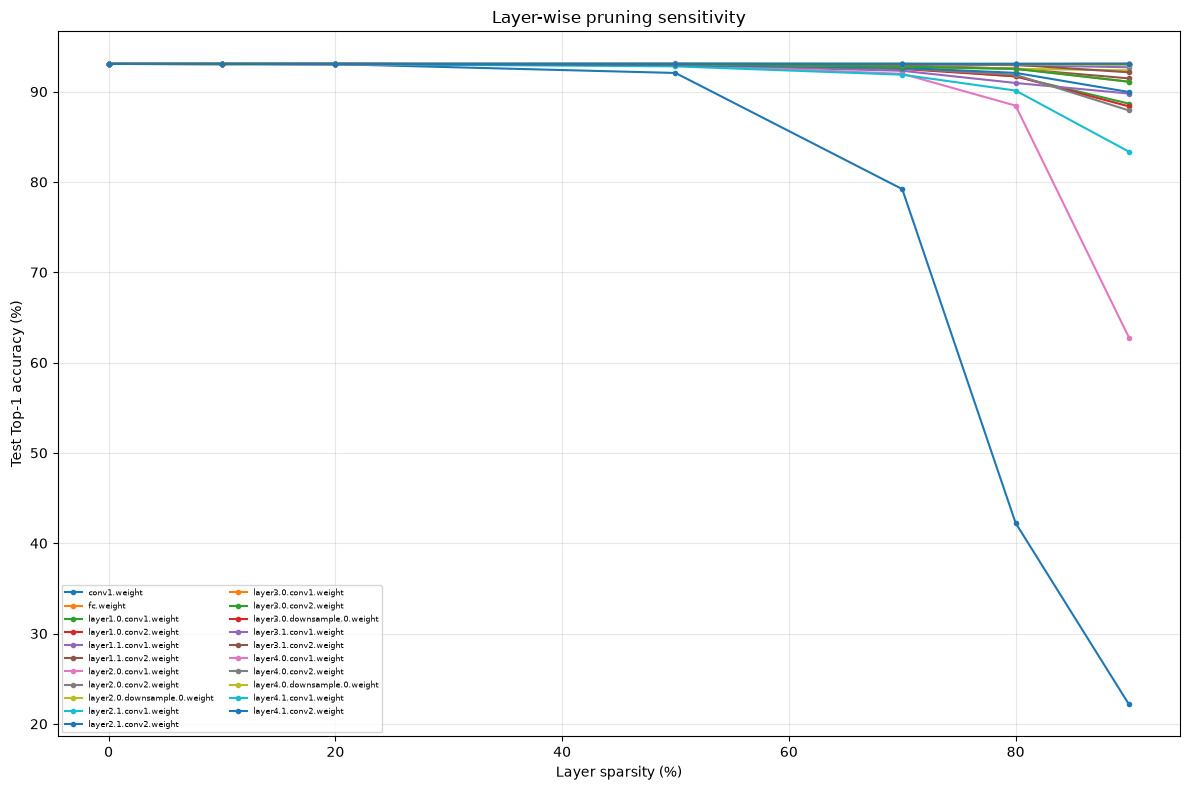

sparsity,0.0,0.1,0.2,0.5,0.7,0.8,0.9
layer,,,,,,,
conv1.weight,93.07,93.07,93.04,92.07,79.21,42.24,22.15
fc.weight,93.07,93.07,93.07,93.04,93.06,93.08,93.09
layer1.0.conv1.weight,93.07,93.07,93.09,92.93,92.65,91.69,88.67
layer1.0.conv2.weight,93.07,93.05,93.09,92.94,92.51,91.70,88.37
layer1.1.conv1.weight,93.07,93.05,93.01,92.96,92.31,90.96,89.79
layer1.1.conv2.weight,93.07,93.06,93.08,92.98,92.90,92.54,91.47
layer2.0.conv1.weight,93.07,93.09,93.03,92.97,91.98,88.45,62.77
layer2.0.conv2.weight,93.07,93.06,93.03,92.93,92.57,91.86,87.92
layer2.0.downsample.0.weight,93.07,93.03,93.08,93.00,92.69,92.53,92.36


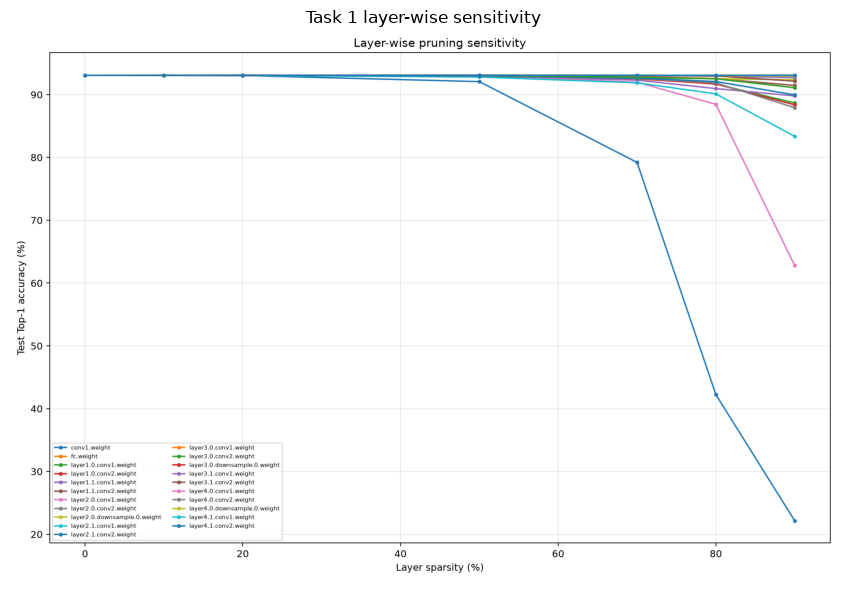

In [20]:
if TASK1_ACTIVE:
    clear_stop_if_resuming()
    print(
        f"Task 1.2 sensitivity uses num_workers=0 for stability. "
        f"Resume from {len(json.loads((DIRS['results'] / 'task1_sensitivity.json').read_text())) if (DIRS['results'] / 'task1_sensitivity.json').exists() else 0} saved rows.",
        flush=True,
    )
    TASK1_SENSITIVITY = run_sensitivity_analysis(TASK1_DATA, TASK1_DENSE_STATE)
    sensitivity_table = TASK1_SENSITIVITY.pivot(
        index="layer", columns="sparsity", values="test_top1").sort_index()
    display(sensitivity_table)
    display_saved_figure(DIRS["figures"] / "task1_sensitivity.png",
                         "Task 1 layer-wise sensitivity")


### Task 1.3 — Allocate masks and fine-tune local and global models

The cell starts at 80%. It uses 75% and then 70% only when either method loses more than 15 percentage points after fine-tuning. Epoch results print as training runs.



Preparing local and global masks at 80% sparsity...


,Local sparsity,Global sparsity
conv1.weight,0.100116,0.170139
layer1.0.conv1.weight,0.200005,0.269151
layer1.0.conv2.weight,0.000000,0.107612
layer1.1.conv1.weight,0.000000,0.118001
layer1.1.conv2.weight,0.000000,0.136827
layer2.0.conv1.weight,0.100003,0.115044
layer2.0.conv2.weight,0.100003,0.123311
layer2.0.downsample.0.weight,0.000000,0.079346
layer2.1.conv1.weight,0.117933,0.135844
layer2.1.conv2.weight,0.199999,0.174581


,Global magnitude threshold
0,0.000869


evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

...

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

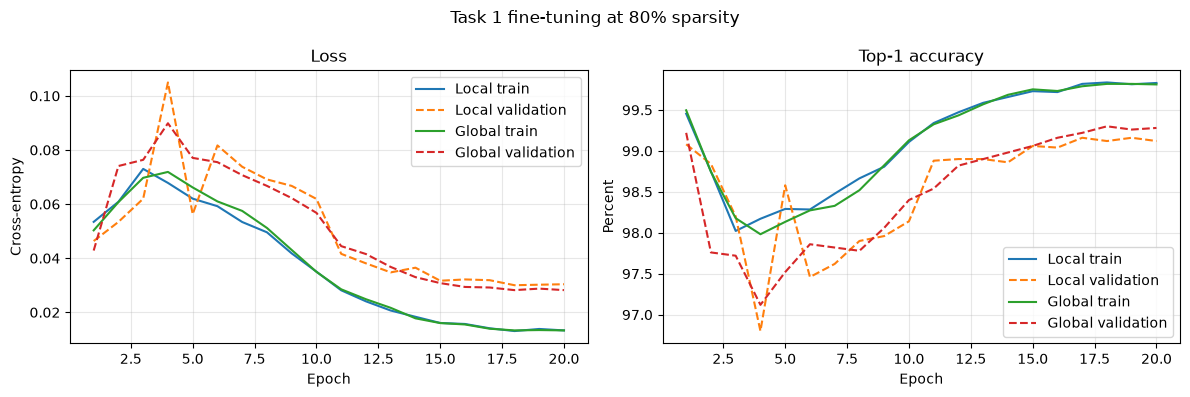

,Target,Local test Top-1 after (%),Global test Top-1 after (%),Local drop (pp),Global drop (pp),Accepted
0,0.8,92.99,92.82,0.08,0.25,True


In [21]:
if TASK1_ACTIVE:
    clear_stop_if_resuming()
    sens_path = DIRS["results"] / "task1_sensitivity.json"
    if not sens_path.exists():
        raise RuntimeError("Run Task 1.2 first to create task1_sensitivity.json.")
    if "TASK1_SENSITIVITY" not in globals():
        TASK1_SENSITIVITY = pd.read_json(sens_path)
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming Task 1.")
        STOP_REQUESTED.clear()
    TASK1_SELECTED = None
    dense_test_top1 = TASK1_BASELINE["evaluations"]["test"]["top1"]
    for target in CONFIG.target_fallbacks:
        print(f"\nPreparing local and global masks at {target:.0%} sparsity...", flush=True)
        local_model = resnet18(pretrained=False).to(DEVICE)
        local_model.load_state_dict(TASK1_DENSE_STATE, strict=True)
        local_counts = local_counts_from_sensitivity(local_model, TASK1_SENSITIVITY, target)
        local_masks = masks_from_local_counts(local_model, local_counts)
        apply_masks(local_model, local_masks)

        global_model = resnet18(pretrained=False).to(DEVICE)
        global_model.load_state_dict(TASK1_DENSE_STATE, strict=True)
        global_masks = global_magnitude_masks(global_model, target)
        dense_global_parameters = dict(eligible_named_parameters(global_model))
        pruned_global_scores = torch.cat([
            dense_global_parameters[name].detach().abs().cpu()[~mask].flatten()
            for name, mask in global_masks.items() if (~mask).any()
        ])
        global_threshold = float(pruned_global_scores.max().item()) if pruned_global_scores.numel() else 0.0
        apply_masks(global_model, global_masks)
        if not math.isclose(mask_sparsity(local_masks), mask_sparsity(global_masks), abs_tol=1e-12):
            raise AssertionError("Local and global overall sparsities differ")

        layer_table = pd.DataFrame({
            "Local sparsity": layer_sparsities(local_masks),
            "Global sparsity": layer_sparsities(global_masks),
        })
        display(layer_table)
        display(pd.DataFrame([{"Global magnitude threshold": global_threshold}]))
        local_pre = evaluate_pruned_model(local_model, TASK1_DATA)
        global_pre = evaluate_pruned_model(global_model, TASK1_DATA)
        display(pd.DataFrame([
            {"Method": "Local", "Test Top-1 before (%)": local_pre["test"]["top1"]},
            {"Method": "Global", "Test Top-1 before (%)": global_pre["test"]["top1"]},
        ]))

        print("Fine-tuning the local model...", flush=True)
        local_run = train_model(local_model, TASK1_DATA, f"task1_local_{int(target*100)}",
                                "task1", CONFIG.task1_epochs, CONFIG.fine_tune_lr, local_masks)
        if local_run["interrupted"]:
            raise RuntimeError("Local fine-tuning stopped after a safe checkpoint; rerun this cell")
        print("Fine-tuning the global model...", flush=True)
        global_run = train_model(global_model, TASK1_DATA, f"task1_global_{int(target*100)}",
                                 "task1", CONFIG.task1_epochs, CONFIG.fine_tune_lr, global_masks)
        if global_run["interrupted"]:
            raise RuntimeError("Global fine-tuning stopped after a safe checkpoint; rerun this cell")

        local_model, global_model = local_run["model"], global_run["model"]
        apply_masks(local_model, local_masks)
        apply_masks(global_model, global_masks)
        local_post = evaluate_pruned_model(local_model, TASK1_DATA)
        global_post = evaluate_pruned_model(global_model, TASK1_DATA)
        local_drop = dense_test_top1 - local_post["test"]["top1"]
        global_drop = dense_test_top1 - global_post["test"]["top1"]
        accepted = local_drop <= CONFIG.accuracy_drop_limit_pp and global_drop <= CONFIG.accuracy_drop_limit_pp
        selection = {
            "target": target, "dense_test_top1": dense_test_top1,
            "local_drop_pp": local_drop, "global_drop_pp": global_drop,
            "accepted": accepted,
        }
        atomic_write_json(DIRS["results"] / f"task1_target_{int(target*100)}_selection.json", selection)
        plot_history({"Local": local_run["history"], "Global": global_run["history"]},
                     DIRS["figures"] / f"task1_training_{int(target*100)}.png",
                     f"Task 1 fine-tuning at {target:.0%} sparsity")
        display(pd.DataFrame([{
            "Target": target, "Local test Top-1 after (%)": local_post["test"]["top1"],
            "Global test Top-1 after (%)": global_post["test"]["top1"],
            "Local drop (pp)": local_drop, "Global drop (pp)": global_drop,
            "Accepted": accepted,
        }]))
        if accepted:
            TASK1_SELECTED = {
                "target": target,
                "local": {"model": local_model, "masks": local_masks, "pre": local_pre,
                          "post": local_post, "history": local_run["history"],
                          "metadata": {"allocation": "sensitivity-curve greedy allocation", "maximum_layer_sparsity": 0.90}},
                "global": {"model": global_model, "masks": global_masks, "pre": global_pre,
                           "post": global_post, "history": global_run["history"],
                           "metadata": {"global_magnitude_threshold": global_threshold}},
            }
            break
        print("The accuracy constraint was not met. Trying the next lower target.", flush=True)
    if TASK1_SELECTED is None:
        raise RuntimeError("No target in 80%, 75%, or 70% met the accuracy-drop constraint")


### Task 1.4 — Verify masks, export COO, and profile

This cell checks every mask, validates exact COO tensor and prediction round trips, and profiles dense-masked and supported COO inference.


In [22]:
if TASK1_ACTIVE:
    target = TASK1_SELECTED["target"]
    task1_records = {}
    for method in ("local", "global"):
        item = TASK1_SELECTED[method]
        print(f"Finalizing and profiling Task 1 {method} pruning...", flush=True)
        task1_records[method] = task1_method_record(
            method, target, item["model"], item["masks"],
            item["pre"], item["post"], item["history"], item.get("metadata"))
    TASK1_RESULT = {
        "config_hash": CONFIG_HASH, "selected_target_sparsity": target,
        "methods": task1_records,
        "sensitivity_path": str(DIRS["results"] / "task1_sensitivity.json"),
    }
    atomic_write_json(DIRS["results"] / "task1.json", TASK1_RESULT)
    display(pd.DataFrame([{
        "Method": name.title(), "Overall sparsity": item["overall_sparsity"],
        "Test Top-1 before (%)": item["pre_finetune"]["test"]["top1"],
        "Test Top-1 after (%)": item["post_finetune"]["test"]["top1"],
        "COO size (MB)": item["coo"]["size_mb"],
        "COO prediction match": item["coo"]["roundtrip_prediction_match"],
    } for name, item in task1_records.items()]))


Finalizing and profiling Task 1 local pruning...


/tmp/ipykernel_983995/1604964892.py:32: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  restored = torch.sparse_coo_tensor(item["indices"], item["values"], item["shape"]).to_dense()
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Finalizing and profiling Task 1 global pruning...


,Method,Overall sparsity,Test Top-1 before (%),Test Top-1 after (%),COO size (MB),COO prediction match
0,Local,0.8,92.91,92.99,91.608349,True
1,Global,0.8,93.11,92.82,91.588239,True


#### Layer-wise sensitivity table

sparsity,0.0,0.1,0.2,0.5,0.7,0.8,0.9
layer,,,,,,,
conv1.weight,93.07,93.07,93.04,92.07,79.21,42.24,22.15
fc.weight,93.07,93.07,93.07,93.04,93.06,93.08,93.09
layer1.0.conv1.weight,93.07,93.07,93.09,92.93,92.65,91.69,88.67
layer1.0.conv2.weight,93.07,93.05,93.09,92.94,92.51,91.70,88.37
layer1.1.conv1.weight,93.07,93.05,93.01,92.96,92.31,90.96,89.79
layer1.1.conv2.weight,93.07,93.06,93.08,92.98,92.90,92.54,91.47
layer2.0.conv1.weight,93.07,93.09,93.03,92.97,91.98,88.45,62.77
layer2.0.conv2.weight,93.07,93.06,93.03,92.93,92.57,91.86,87.92
layer2.0.downsample.0.weight,93.07,93.03,93.08,93.00,92.69,92.53,92.36


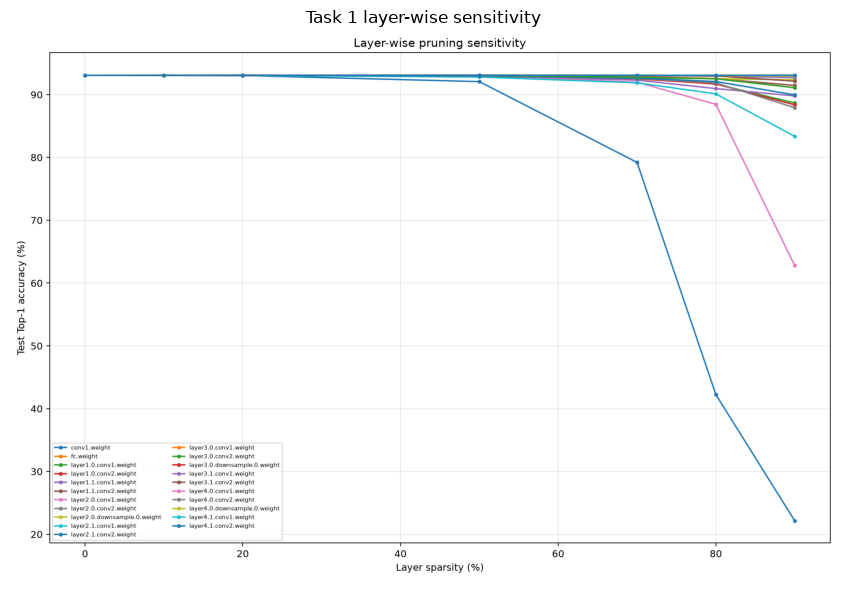

#### Final Task 1 results at 80% sparsity

,Method,Overall sparsity,Train Top-1 (%),Test Top-1 before (%),Test Top-1 after (%),Train Top-5 (%),Test Top-5 (%),Macro-F1 (%),Recovered accuracy (pp),Parameters,Executed MACs,Executed FLOPs,Mean latency (ms),Average GPU memory (MB),Peak GPU memory (MB),CPU energy (J),GPU energy (J),CPU energy (J/image),GPU energy (J/image)
0,Local,0.8,99.86,92.91,92.99,100.000,99.77,92.989330,0.08,11173962,140186624,280373248,12.169921,343.204864,477.412352,658.818016,1919.102079,0.001287,0.003748
1,Global,0.8,99.89,93.11,92.82,99.998,99.75,92.811142,-0.29,11173962,140186624,280373248,12.291313,343.204864,477.412352,645.913142,1932.991996,0.001262,0.003775


#### Layer-wise sparsity

Method,Global,Local
Layer,,
conv1.weight,0.170139,0.100116
fc.weight,0.001563,0.200000
layer1.0.conv1.weight,0.269151,0.200005
layer1.0.conv2.weight,0.107612,0.000000
layer1.1.conv1.weight,0.118001,0.000000
layer1.1.conv2.weight,0.136827,0.000000
layer2.0.conv1.weight,0.115044,0.100003
layer2.0.conv2.weight,0.123311,0.100003
layer2.0.downsample.0.weight,0.079346,0.000000


#### Dense and COO storage

,Method,Dense weights (MB),Dense weights and masks (MB),COO total (MB),COO values (bytes),COO indices (bytes),COO masks (bytes),COO prediction match,Dense-kernel MACs,Theoretical nonzero MACs
0,Local,44.770379,55.941345,91.608349,8931480,71386304,11164352,True,140186624,82324740
1,Global,44.770379,55.937417,91.588239,8931480,71370048,11164352,True,140186624,82707636


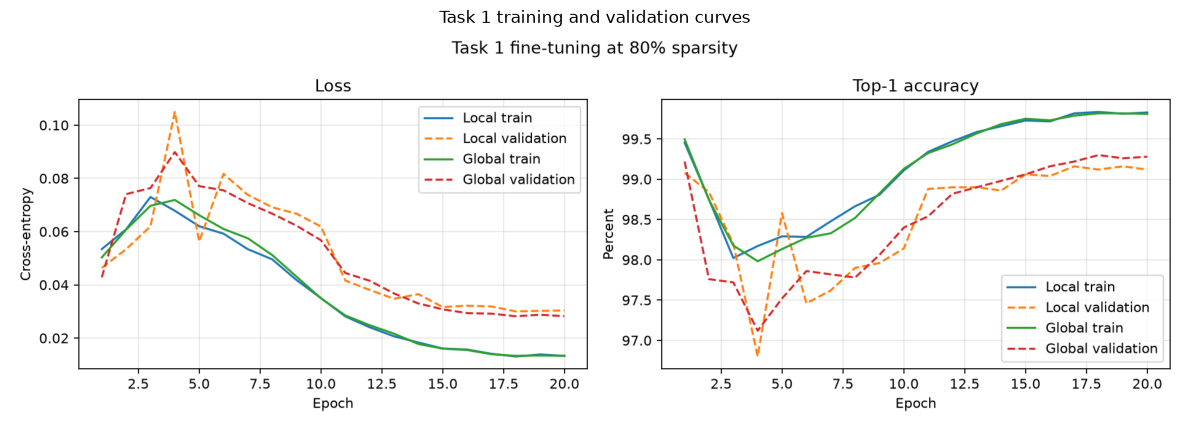


#### Task 1 discussion

The most sensitive layer was **conv1.weight**.
Global pruning produced different sparsities for different layers, and the mask checks prevent a complete layer collapse.
Local fine-tuning recovered **0.08** percentage points.
Global fine-tuning recovered **-0.29** percentage points.
COO was smaller than the local dense masked package: **False**.
A zero-valued weight still uses a dense convolution operation. This is why unstructured pruning may not reduce latency.


In [23]:
# Show Task 1 tables, graphs, and discussion in this section.
_sensitivity_path = DIRS["results"] / "task1_sensitivity.json"
if _sensitivity_path.exists():
    _sensitivity = pd.read_json(_sensitivity_path)
    display(Markdown("#### Layer-wise sensitivity table"))
    display(_sensitivity.pivot(index="layer", columns="sparsity", values="test_top1").sort_index())
    display_saved_figure(DIRS["figures"] / "task1_sensitivity.png", "Task 1 layer-wise sensitivity")

_task1_path = DIRS["results"] / "task1.json"
if _task1_path.exists():
    _task1 = json.loads(_task1_path.read_text())
    _target = float(_task1["selected_target_sparsity"])
    _summary_rows, _layer_rows, _storage_rows = [], [], []
    for _method, _item in _task1["methods"].items():
        _summary_rows.append({
            "Method": _method.title(),
            "Overall sparsity": _item["overall_sparsity"],
            "Train Top-1 (%)": _item["post_finetune"]["full_train"]["top1"],
            "Test Top-1 before (%)": _item["pre_finetune"]["test"]["top1"],
            "Test Top-1 after (%)": _item["post_finetune"]["test"]["top1"],
            "Train Top-5 (%)": _item["post_finetune"]["full_train"]["top5"],
            "Test Top-5 (%)": _item["post_finetune"]["test"]["top5"],
            "Macro-F1 (%)": _item["post_finetune"]["test"]["macro_f1"],
            "Recovered accuracy (pp)": _item["accuracy_recovered_pp"],
            "Parameters": _item["dense_profile"]["parameters"],
            "Executed MACs": _item["dense_profile"]["macs"],
            "Executed FLOPs": _item["dense_profile"]["flops"],
            "Mean latency (ms)": _item["dense_profile"]["latency_mean_batch_ms"],
            "Average GPU memory (MB)": _item["dense_profile"]["gpu_memory_average_mb"],
            "Peak GPU memory (MB)": _item["dense_profile"]["gpu_memory_peak_mb"],
            "CPU energy (J)": _item["dense_profile"]["cpu_energy_j"],
            "GPU energy (J)": _item["dense_profile"]["gpu_energy_j"],
            "CPU energy (J/image)": _item["dense_profile"]["cpu_energy_j_per_image"],
            "GPU energy (J/image)": _item["dense_profile"]["gpu_energy_j_per_image"],
        })
        for _layer, _sparsity in _item["layer_sparsity"].items():
            _layer_rows.append({"Layer": _layer, "Method": _method.title(), "Sparsity": _sparsity})
        _storage_rows.append({
            "Method": _method.title(),
            "Dense weights (MB)": _item["dense_weights_size_mb"],
            "Dense weights and masks (MB)": _item["dense_masked_size_mb"],
            "COO total (MB)": _item["coo"]["size_mb"],
            "COO values (bytes)": _item["coo"]["values_bytes"],
            "COO indices (bytes)": _item["coo"]["indices_bytes"],
            "COO masks (bytes)": _item["coo"]["mask_bytes"],
            "COO prediction match": _item["coo"].get("roundtrip_prediction_match"),
            "Dense-kernel MACs": _item["dense_kernel_macs"],
            "Theoretical nonzero MACs": _item["theoretical_nonzero_macs"],
        })
    display(Markdown(f"#### Final Task 1 results at {_target:.0%} sparsity"))
    display(pd.DataFrame(_summary_rows))
    display(Markdown("#### Layer-wise sparsity"))
    display(pd.DataFrame(_layer_rows).pivot(index="Layer", columns="Method", values="Sparsity"))
    display(Markdown("#### Dense and COO storage"))
    display(pd.DataFrame(_storage_rows))
    display_saved_figure(
        DIRS["figures"] / f"task1_training_{int(_target*100)}.png",
        "Task 1 training and validation curves")
    if _sensitivity_path.exists():
        _dense_top1 = json.loads((DIRS["results"] / "task0.json").read_text())["evaluations"]["test"]["top1"]
        _at_90 = _sensitivity[_sensitivity["sparsity"] == 0.90].copy()
        _at_90["drop"] = _dense_top1 - _at_90["test_top1"]
        _most_sensitive = _at_90.sort_values("drop", ascending=False).iloc[0]["layer"]
        _local, _global = _task1["methods"]["local"], _task1["methods"]["global"]
        _coo_smaller = _local["coo"]["size_mb"] < _local["dense_masked_size_mb"]
        display(Markdown(f"""
#### Task 1 discussion

The most sensitive layer was **{_most_sensitive}**.
Global pruning produced different sparsities for different layers, and the mask checks prevent a complete layer collapse.
Local fine-tuning recovered **{_local['accuracy_recovered_pp']:.2f}** percentage points.
Global fine-tuning recovered **{_global['accuracy_recovered_pp']:.2f}** percentage points.
COO was smaller than the local dense masked package: **{_coo_smaller}**.
A zero-valued weight still uses a dense convolution operation. This is why unstructured pruning may not reduce latency.
"""))
else:
    display(Markdown("Task 1 is not complete. Run Task 1.1 through Task 1.4 above."))


### Task 1 Results: Unstructured Magnitude Pruning

The final target was **80% overall sparsity** for both local and global pruning.

| Metric | Local | Global |
|---|---:|---:|
| Train Top-1 | 99.86% | 99.89% |
| Test Top-1 before fine-tuning | 92.91% | 93.11% |
| Test Top-1 after fine-tuning | 92.99% | 92.82% |
| Test Top-5 | 99.77% | 99.75% |
| Macro-F1 | 92.99% | 92.81% |
| Accuracy recovered by fine-tuning | +0.08 pp | -0.29 pp |
| Dense weight size | 44.77 MB | 44.77 MB |
| COO package size | 91.61 MB | 91.59 MB |
| Mean dense-masked latency | 12.17 ms | 12.29 ms |
| Average GPU memory | 343.20 MB | 343.20 MB |
| Peak GPU memory | 477.41 MB | 477.41 MB |
| CPU energy | 0.001287 J/image | 0.001262 J/image |
| GPU energy | 0.003748 J/image | 0.003775 J/image |

**Discussion**
- **Most sensitive layers:** `conv1.weight` was clearly the most sensitive. At 90% sparsity its test accuracy dropped to **22.15%**. `layer2.0.conv1.weight` was also sensitive at high sparsity.
- **Global sparsity distribution:** It was strongly non-uniform, which is expected from global magnitude pruning. No layer was completely pruned, although some late layers became more than 95% sparse.
- **Fine-tuning recovery:** Local pruning recovered **0.08 pp**. Global pruning did not recover accuracy and finished **0.29 pp lower** than its pre-fine-tuning value.
- **COO storage:** COO did **not** reduce the saved size here. The local COO package was **91.61 MB**, larger than both the dense weights (**44.77 MB**) and the dense weights plus masks (**55.94 MB**) because COO also stores indices and masks.
- **Latency:** Unstructured zeros do not automatically make dense convolution faster. The tensor shapes are unchanged and the dense convolution kernels still process the zero-valued positions.

For the sparse inference path, the linear classifier uses `torch.sparse.mm`. Convolution weights still have to be converted/reconstructed as dense tensors before normal convolution, so most of the network still uses dense kernels.

Mask verification completed without errors, so the pruned weights remained zero after fine-tuning.



## Task 2: Saliency-Based Iterative Pruning (GraSP)

Train ResNet-18 **from random initialization** (not the Task 0 checkpoint). Compare iterative magnitude pruning and iterative GraSP with identical warm-up, budget, and target sparsity $s^\star$ from Task 1.


Both methods start from one random initialization and one warm-up checkpoint. The total budget is 100 epochs, including warm-up.

$$
g=\nabla_\theta L(\theta)
$$

$$
Hg=\nabla_\theta^2L(\theta)g
$$

$$
S_i=-\theta_i(Hg)_i
$$

$$
M_{\mathrm{cum},k}^{(\ell)}=M_{\mathrm{cum},k-1}^{(\ell)}\odot M_k^{(\ell)}
$$


In [14]:
# GraSP criterion and correctness tests.
def model_state_hash(model):
    stream = io.BytesIO()
    torch.save(cpu_model_state(model), stream)
    return hashlib.sha256(stream.getvalue()).hexdigest()


def verify_hessian_vector_product():
    dtype = torch.float64
    x = torch.tensor([0.2, -0.4, 0.7], dtype=dtype, requires_grad=True)
    matrix = torch.tensor([[3.0, 0.2, -0.1], [0.2, 2.0, 0.4], [-0.1, 0.4, 1.5]], dtype=dtype)
    vector = torch.tensor([0.5, -0.3, 0.2], dtype=dtype)
    loss = 0.5 * x @ matrix @ x
    gradient = torch.autograd.grad(loss, x, create_graph=True)[0]
    exact = torch.autograd.grad((gradient * vector).sum(), x)[0]
    epsilon = 1e-5
    def gradient_at(value):
        value = value.detach().requires_grad_(True)
        objective = 0.5 * value @ matrix @ value
        return torch.autograd.grad(objective, value)[0]
    finite = (gradient_at(x + epsilon * vector) - gradient_at(x - epsilon * vector)) / (2 * epsilon)
    if not torch.allclose(exact, finite, rtol=1e-5, atol=1e-7):
        raise AssertionError(f"Hessian-vector check failed: {exact} versus {finite}")
    return {"autograd": exact.tolist(), "finite_difference": finite.tolist()}


def verify_score_sorting():
    scores = torch.tensor([-2.0, -0.5, 0.1, 3.0])
    prune = torch.topk(scores, 2, largest=True).indices
    if set(prune.tolist()) != {2, 3}:
        raise AssertionError("GraSP sorting must prune the largest scores")
    return {
        "scores": scores.tolist(),
        "pruned_indices": prune.tolist(),
        "rule": "prune largest score"
    }


def grasp_importance(model, loader, masks):
    # A copy prevents calibration passes from changing the live model's BatchNorm state.
    working = copy.deepcopy(model).to(DEVICE).train()
    named = dict(eligible_named_parameters(working))
    names = list(named)
    parameters = [named[name] for name in names]
    active_masks = [masks[name].to(DEVICE, dtype=parameter.dtype)
                    for name, parameter in zip(names, parameters)]
    batches = list(loader)
    average_gradient = [torch.zeros_like(parameter) for parameter in parameters]

    for images, labels in batches:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        loss = F.cross_entropy(working(images), labels)
        gradients = torch.autograd.grad(loss, parameters, create_graph=False)
        for accumulator, gradient, active in zip(average_gradient, gradients, active_masks):
            accumulator.add_(gradient.detach() * active / len(batches))

    hessian_gradient = [torch.zeros_like(parameter) for parameter in parameters]
    for images, labels in batches:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        loss = F.cross_entropy(working(images), labels)
        gradients = torch.autograd.grad(loss, parameters, create_graph=True)
        dot = sum((gradient * direction).sum()
                  for gradient, direction in zip(gradients, average_gradient))
        products = torch.autograd.grad(dot, parameters, create_graph=False)
        for accumulator, product in zip(hessian_gradient, products):
            accumulator.add_(product.detach() / len(batches))

    normalizer = sum(item.abs().sum() for item in hessian_gradient).clamp_min(1e-12)
    scores = {}
    for name, parameter, product, active in zip(names, parameters, hessian_gradient, active_masks):
        scores[name] = (-parameter.detach() * product / normalizer) * active
    del working
    return scores


In [15]:
# Resumable iterative training state machine.
def stage_evaluation(model, data):
    return {
        "train": evaluate_model(model, evaluation_loader(data.full_train_eval)),
        "validation": evaluate_model(model, evaluation_loader(data.validation)),
        "test": evaluate_model(model, evaluation_loader(data.test)),
    }


def iterative_checkpoint(task_name, phase, model, optimizer, scheduler, masks,
                         epoch, next_batch, global_step, history, epoch_accum,
                         sampler_state, stage_index, stage_records, criterion_times,
                         initial_hash, calibration_indices):
    return build_training_checkpoint(
        "task2", phase, model, optimizer, scheduler, masks, epoch, next_batch,
        global_step, history, epoch_accum, sampler_state,
        {
            "method": task_name, "stage_index": stage_index,
            "stage_records": stage_records, "criterion_times": criterion_times,
            "initial_hash": initial_hash,
            "calibration_indices": list(map(int, calibration_indices)),
        })


def train_iterative_method(method, data, warm_checkpoint, target, initial_hash):
    run_name = f"task2_{method}_{int(target*100)}"
    manager = CheckpointManager(run_name)
    model = resnet18().to(DEVICE)
    model.load_state_dict(warm_checkpoint["model_state"], strict=True)
    masks = initial_masks(model)
    apply_masks(model, masks)
    steps_per_epoch = math.ceil(len(data.train_augmented) / CONFIG.batch_size)
    optimizer = make_optimizer(model, CONFIG.learning_rate)
    scheduler = make_scheduler(optimizer, CONFIG.task2_epochs * steps_per_epoch)
    optimizer.load_state_dict(warm_checkpoint["optimizer_state"])
    scheduler.load_state_dict(warm_checkpoint["scheduler_state"])
    optimizer_to_device(optimizer, DEVICE)

    epoch = int(warm_checkpoint["epoch"])
    next_batch = 0
    global_step = int(warm_checkpoint["global_step"])
    history = list(warm_checkpoint["history"])
    epoch_accum = {"loss_sum": 0.0, "correct": 0, "samples": 0}
    stage_index, stage_records, criterion_times = 0, [], []
    resume_pending_stage = None
    saved = manager.load()
    if saved:
        model.load_state_dict(saved["model_state"], strict=True)
        optimizer.load_state_dict(saved["optimizer_state"])
        scheduler.load_state_dict(saved["scheduler_state"])
        optimizer_to_device(optimizer, DEVICE)
        masks = {key: value.bool().cpu() for key, value in saved["masks"].items()}
        apply_masks(model, masks)
        epoch, next_batch, global_step = saved["epoch"], saved["next_batch"], saved["global_step"]
        history, epoch_accum = saved["history"], saved["epoch_accum"]
        extra = saved["extra"]
        stage_index = extra["stage_index"]
        stage_records = extra["stage_records"]
        criterion_times = extra["criterion_times"]
        if extra["initial_hash"] != initial_hash:
            raise RuntimeError("Task 2 initialization hash mismatch")
        set_rng_state(saved["rng_state"])
        if saved["phase"] == "complete":
            return model, masks, history, stage_records, criterion_times
        if str(saved["phase"]).startswith("before_stage_"):
            resume_pending_stage = int(str(saved["phase"]).rsplit("_", 1)[1]) - 1

    targets = [0.50 * target, 0.75 * target, target]
    thresholds = [20.0, 40.0, 60.0]
    fallback_epochs = [10, 35, 60]

    def apply_stage(index, trigger_accuracy, trigger_reason):
        nonlocal masks
        before = stage_evaluation(model, data)
        before_state = iterative_checkpoint(
            method, f"before_stage_{index+1}", model, optimizer, scheduler, masks,
            epoch, next_batch, global_step, history, epoch_accum, None,
            index, stage_records, criterion_times, initial_hash, data.calibration_indices)
        manager.save(before_state, milestone=f"before_stage_{index+1}")
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        started = time.perf_counter()
        if method == "magnitude":
            new_masks = global_magnitude_masks(model, targets[index], masks)
        elif method == "grasp":
            scores = grasp_importance(model, calibration_loader(data), masks)

            # exact_mask_from_importance prunes the smallest values,
            # so negate GraSP scores to effectively prune the largest scores.
            grasp_pruning_importance = {
                name: -score for name, score in scores.items()
            }

            new_masks = exact_mask_from_importance(
                model,
                grasp_pruning_importance,
                targets[index],
                masks
            )
        else:
            raise ValueError(method)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        criterion_seconds = time.perf_counter() - started
        previous_active = sum(value.count_nonzero().item() for value in masks.values())
        new_active = sum(value.count_nonzero().item() for value in new_masks.values())
        if new_active > previous_active:
            raise AssertionError("A cumulative mask reactivated a pruned weight")
        masks = new_masks
        apply_masks(model, masks)
        after = stage_evaluation(model, data)
        record = {
            "stage": index + 1, "target_sparsity": targets[index],
            "measured_sparsity": mask_sparsity(masks),
            "trigger_accuracy": trigger_accuracy, "trigger_reason": trigger_reason,
            "epoch": epoch, "before": before, "after": after,
            "criterion_seconds": criterion_seconds,
        }
        stage_records.append(record)
        criterion_times.append(criterion_seconds)
        after_state = iterative_checkpoint(
            method, f"after_stage_{index+1}", model, optimizer, scheduler, masks,
            epoch, next_batch, global_step, history, epoch_accum, None,
            index + 1, stage_records, criterion_times, initial_hash, data.calibration_indices)
        manager.save(after_state, milestone=f"after_stage_{index+1}")
        atomic_write_json(DIRS["results"] / f"{run_name}_stages.json", stage_records)

    warm_accuracy = history[-1]["val_top1"] if history else 0.0
    if resume_pending_stage is not None:
        apply_stage(resume_pending_stage, warm_accuracy, "resumed unfinished pruning stage")
        stage_index = resume_pending_stage + 1
    elif stage_index == 0:
        apply_stage(0, warm_accuracy, "validation threshold" if warm_accuracy >= 20.0 else "fallback epoch 10")
        stage_index = 1

    while epoch < CONFIG.task2_epochs:
        model.train()
        loader, sampler = training_loader(data, epoch, next_batch)
        for relative_batch, (images, labels) in enumerate(loader):
            absolute_batch = next_batch + relative_batch
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            apply_masks(model, masks)
            scheduler.step()
            count = labels.numel()
            epoch_accum["loss_sum"] += loss.item() * count
            epoch_accum["correct"] += logits.argmax(1).eq(labels).sum().item()
            epoch_accum["samples"] += count
            global_step += 1
            completed_next = absolute_batch + 1
            if global_step % CONFIG.checkpoint_steps == 0 or STOP_REQUESTED.is_set():
                state = iterative_checkpoint(
                    method, "training", model, optimizer, scheduler, masks,
                    epoch, completed_next, global_step, history, epoch_accum,
                    {**sampler.state_dict(), "start_batch": completed_next},
                    stage_index, stage_records, criterion_times, initial_hash,
                    data.calibration_indices)
                manager.save(state)
            if STOP_REQUESTED.is_set():
                return model, masks, history, stage_records, criterion_times
        train_loss = epoch_accum["loss_sum"] / epoch_accum["samples"]
        train_top1 = 100.0 * epoch_accum["correct"] / epoch_accum["samples"]
        validation = evaluate_model(model, evaluation_loader(data.validation))
        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "train_top1": train_top1,
            "val_loss": validation["loss"], "val_top1": validation["top1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        })
        epoch += 1
        next_batch = 0
        epoch_accum = {"loss_sum": 0.0, "correct": 0, "samples": 0}

        if stage_index < 3:
            threshold_met = validation["top1"] >= thresholds[stage_index]
            fallback_met = epoch >= fallback_epochs[stage_index]
            if threshold_met or fallback_met:
                reason = "validation accuracy threshold" if threshold_met else f"fallback epoch {fallback_epochs[stage_index]}"
                apply_stage(stage_index, validation["top1"], reason)
                stage_index += 1

        state = iterative_checkpoint(
            method, "training", model, optimizer, scheduler, masks,
            epoch, 0, global_step, history, epoch_accum, None,
            stage_index, stage_records, criterion_times, initial_hash,
            data.calibration_indices)
        manager.save(state, milestone=f"epoch_{epoch:03d}")
        atomic_write_json(DIRS["results"] / f"{run_name}_history.json", history)

    if stage_index != 3:
        raise RuntimeError("Training budget ended before all three pruning stages")
    state = iterative_checkpoint(
        method, "complete", model, optimizer, scheduler, masks,
        epoch, 0, global_step, history, epoch_accum, None,
        stage_index, stage_records, criterion_times, initial_hash,
        data.calibration_indices)
    manager.save(state, milestone="complete")
    return model, masks, history, stage_records, criterion_times


In [16]:
def get_task2_warmup(data):
    manager = CheckpointManager("task2_warmup")
    saved = manager.load()
    if saved and saved["phase"] == "warmup_complete":
        model = resnet18().to(DEVICE)
        model.load_state_dict(saved["model_state"], strict=True)
        return model, saved
    initial_path = DIRS["checkpoints"] / "task2_initial.pt"
    set_all_seeds(CONFIG.seed)
    model = resnet18(pretrained=False).to(DEVICE)
    initial_hash = model_state_hash(model)
    if not initial_path.exists():
        torch.save({"model_state": cpu_model_state(model), "initial_hash": initial_hash}, initial_path)
    else:
        stored = torch.load(initial_path, map_location="cpu", weights_only=False)
        model.load_state_dict(stored["model_state"], strict=True)
        initial_hash = stored["initial_hash"]
    result = train_model(
        model, data, "task2_warmup", "task2", 10,
        CONFIG.learning_rate, masks=None, stop_at_train_accuracy=20.0,
        schedule_epochs=CONFIG.task2_epochs,
        extra={"initial_hash": initial_hash, "calibration_indices": data.calibration_indices.tolist()})
    if result["interrupted"]:
        return result["model"], result["checkpoint"]
    warm = result["checkpoint"]
    if warm["phase"] != "warmup_complete":
        raise RuntimeError("Warm-up did not reach 20% accuracy before the full budget")
    return result["model"], warm


### Task 2.1 — Prepare calibration data and verify GraSP math

The fixed 1,024 sample indices, class labels, batch size, batch count, Hessian-vector test, and score-sorting test are shown here.


In [17]:
TASK2_ACTIVE = task_enabled("task2")
if TASK2_ACTIVE:
    task1_path = DIRS["results"] / "task1.json"
    if not task1_path.exists():
        raise RuntimeError("Complete Task 1 before Task 2")
    TASK2_TASK1 = json.loads(task1_path.read_text())
    if TASK2_TASK1.get("config_hash") != CONFIG_HASH:
        raise RuntimeError("Task 1 results use a different configuration")
    TASK2_TARGET = float(TASK2_TASK1["selected_target_sparsity"])
    TASK2_DATA = load_data()
    hvp_test = verify_hessian_vector_product()
    sorting_test = verify_score_sorting()
    calibration_targets = np.asarray(TASK2_DATA.full_train_eval.base.targets)[TASK2_DATA.calibration_indices]
    calibration_frame = pd.DataFrame({
        "sample_index": TASK2_DATA.calibration_indices.astype(int),
        "class": calibration_targets.astype(int),
    })
    atomic_write_bytes(DIRS["results"] / "task2_calibration_indices.csv",
                       calibration_frame.to_csv(index=False).encode())
    atomic_write_json(DIRS["results"] / "task2_grasp_tests.json", {
        "hessian_vector": hvp_test, "sorting": sorting_test,
    })
    display(pd.DataFrame([{
        "Calibration samples": len(calibration_frame),
        "Calibration batch size": CONFIG.calibration_batch_size,
        "Calibration batches": math.ceil(len(calibration_frame) / CONFIG.calibration_batch_size),
        "Final target sparsity": TASK2_TARGET,
        "Total epoch budget": CONFIG.task2_epochs,
    }]))
    display(calibration_frame)
    display({"Hessian-vector test": hvp_test, "Sorting test": sorting_test})
else:
    print("Task 2 execution is skipped for this RUN_TASK value.")


,Calibration samples,Calibration batch size,Calibration batches,Final target sparsity,Total epoch budget
0,1024,128,8,0.8,100


,sample_index,class
0,9976,3
1,32996,2
2,24089,9
3,6283,7
4,34084,5
...,...,...
1019,37852,5
1020,13011,0
1021,42103,0
1022,5260,3


{'Hessian-vector test': {'autograd': [1.42, -0.42, 0.13000000000000003],
  'finite_difference': [1.4200000000075261,
   -0.41999999999819954,
   0.1299999999870849]},
 'Sorting test': {'scores': [-2.0, -0.5, 0.10000000149011612, 3.0],
  'pruned_indices': [3, 2],
  'rule': 'prune largest score'}}

### Task 2.2 — Create or resume the shared warm-up

Warm-up stops near 20% validation accuracy or uses epoch 10 as the documented fallback.


Resuming from /home/dksg/AIEJ/artifacts/checkpoints/task2_warmup/latest.pt


,Initial-state hash,Warm-up epochs,Warm-up validation Top-1 (%),Trigger reason
0,1f7b0761da53c6f0654eaa0d5bfde4ab84537d26890ffe...,1,48.92,validation threshold


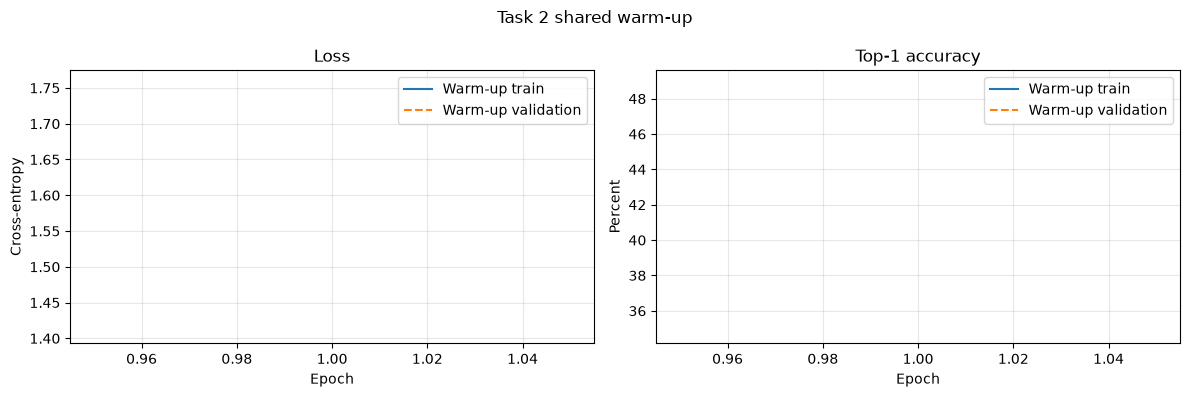

In [18]:
if TASK2_ACTIVE:
    clear_stop_if_resuming()
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming Task 2 warm-up.")
        STOP_REQUESTED.clear()
    TASK2_WARM_MODEL, TASK2_WARM = get_task2_warmup(TASK2_DATA)
    if TASK2_WARM["phase"] != "warmup_complete":
        raise RuntimeError("Warm-up stopped after a safe checkpoint; rerun this cell")
    TASK2_INITIAL_HASH = TASK2_WARM["extra"]["initial_hash"]
    warm_history = pd.DataFrame(TASK2_WARM["history"])
    trigger_reason = "validation threshold" if warm_history.iloc[-1]["val_top1"] >= 20.0 else "fallback epoch 10"
    display(pd.DataFrame([{
        "Initial-state hash": TASK2_INITIAL_HASH,
        "Warm-up epochs": int(TASK2_WARM["epoch"]),
        "Warm-up validation Top-1 (%)": warm_history.iloc[-1]["val_top1"],
        "Trigger reason": trigger_reason,
    }]))
    plot_history({"Warm-up": TASK2_WARM["history"]},
                 DIRS["figures"] / "task2_warmup_training.png",
                 "Task 2 shared warm-up")


### Task 2.3 — Run iterative magnitude pruning

The three pruning stages and each epoch print as they complete. Checkpoints preserve cumulative masks.


Resuming from /home/dksg/AIEJ/artifacts/checkpoints/task2_magnitude_80/latest.pt


,stage,target_sparsity,measured_sparsity,trigger_accuracy,trigger_reason,epoch,before,after,criterion_seconds
0,1,0.4,0.4,48.92,validation threshold,1,"{'train': {'loss': 1.4166212609863282, 'top1':...","{'train': {'loss': 1.4255030361938477, 'top1':...",0.240293
1,2,0.6,0.6,60.78,validation accuracy threshold,2,"{'train': {'loss': 1.0701155361938477, 'top1':...","{'train': {'loss': 1.198398322906494, 'top1': ...",0.227304
2,3,0.8,0.8,64.60,validation accuracy threshold,3,"{'train': {'loss': 0.988242190246582, 'top1': ...","{'train': {'loss': 1.4962344984436036, 'top1':...",0.197938


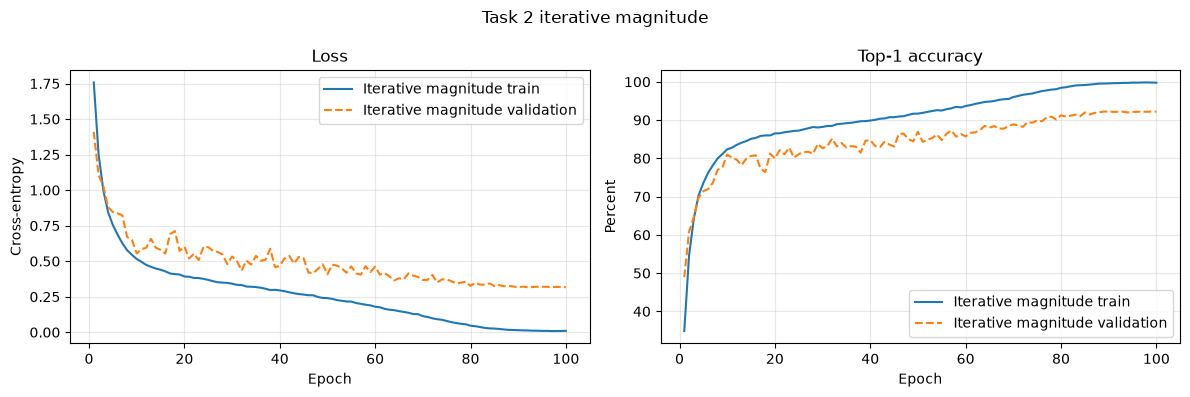

In [19]:
if TASK2_ACTIVE:
    clear_stop_if_resuming()
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming iterative magnitude.")
        STOP_REQUESTED.clear()
    (TASK2_MAG_MODEL, TASK2_MAG_MASKS, TASK2_MAG_HISTORY,
     TASK2_MAG_STAGES, TASK2_MAG_TIMES) = train_iterative_method(
        "magnitude", TASK2_DATA, TASK2_WARM, TASK2_TARGET, TASK2_INITIAL_HASH)
    if STOP_REQUESTED.is_set():
        raise RuntimeError("Iterative magnitude stopped after a safe checkpoint; rerun this cell")
    display(pd.DataFrame(TASK2_MAG_STAGES))
    plot_history({"Iterative magnitude": TASK2_MAG_HISTORY},
                 DIRS["figures"] / "task2_magnitude_training.png",
                 "Task 2 iterative magnitude")


### Task 2.4 — Run iterative GraSP pruning

GraSP recalculates its scores at every stage. Criterion time is recorded separately from training.


Resuming from /home/dksg/AIEJ/artifacts/checkpoints/task2_grasp_80/latest.pt


,stage,target_sparsity,measured_sparsity,trigger_accuracy,trigger_reason,epoch,before,after,criterion_seconds
0,1,0.4,0.4,48.92,validation threshold,1,"{'train': {'loss': 1.4166212609863282, 'top1':...","{'train': {'loss': 7079864.4992, 'top1': 10.0,...",1.426761
1,2,0.6,0.6,46.92,validation accuracy threshold,3,"{'train': {'loss': 1.4360429751586914, 'top1':...","{'train': {'loss': 31.816515805664064, 'top1':...",1.334309
2,3,0.8,0.8,61.72,validation accuracy threshold,7,"{'train': {'loss': 1.0824262322998046, 'top1':...","{'train': {'loss': 6.082938686523438, 'top1': ...",1.325228


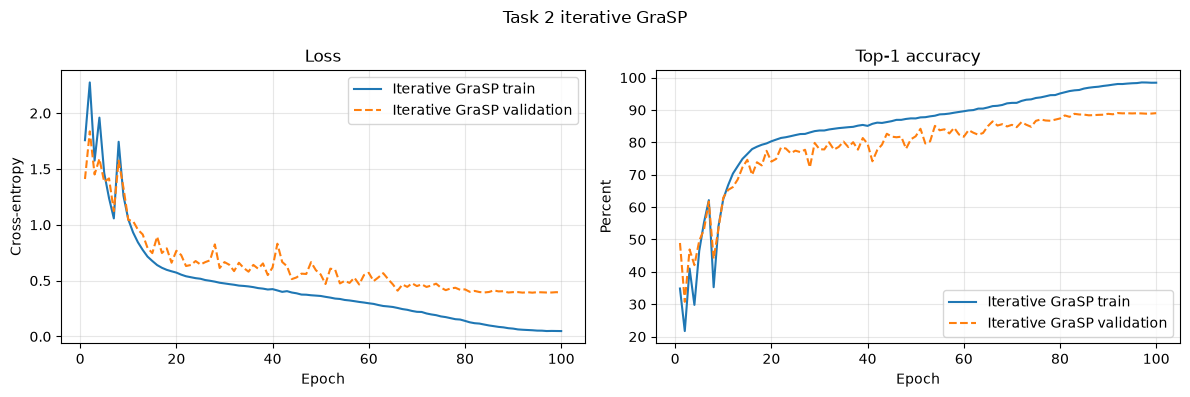

In [20]:
if TASK2_ACTIVE:
    clear_stop_if_resuming()
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming iterative GraSP.")
        STOP_REQUESTED.clear()
    (TASK2_GRASP_MODEL, TASK2_GRASP_MASKS, TASK2_GRASP_HISTORY,
     TASK2_GRASP_STAGES, TASK2_GRASP_TIMES) = train_iterative_method(
        "grasp", TASK2_DATA, TASK2_WARM, TASK2_TARGET, TASK2_INITIAL_HASH)
    if STOP_REQUESTED.is_set():
        raise RuntimeError("Iterative GraSP stopped after a safe checkpoint; rerun this cell")
    display(pd.DataFrame(TASK2_GRASP_STAGES))
    plot_history({"Iterative GraSP": TASK2_GRASP_HISTORY},
                 DIRS["figures"] / "task2_grasp_training.png",
                 "Task 2 iterative GraSP")


### Task 2.5 — Verify, export, profile, and save the comparison

Both final models use the same dense-masked and supported COO profiling procedure used in Task 1.


Verifying, exporting, and profiling iterative magnitude...


evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_1249230/1604964892.py:32: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  restored = torch.sparse_coo_tensor(item["indices"], item["values"], item["shape"]).to_dense()
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Verifying, exporting, and profiling iterative grasp...


evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

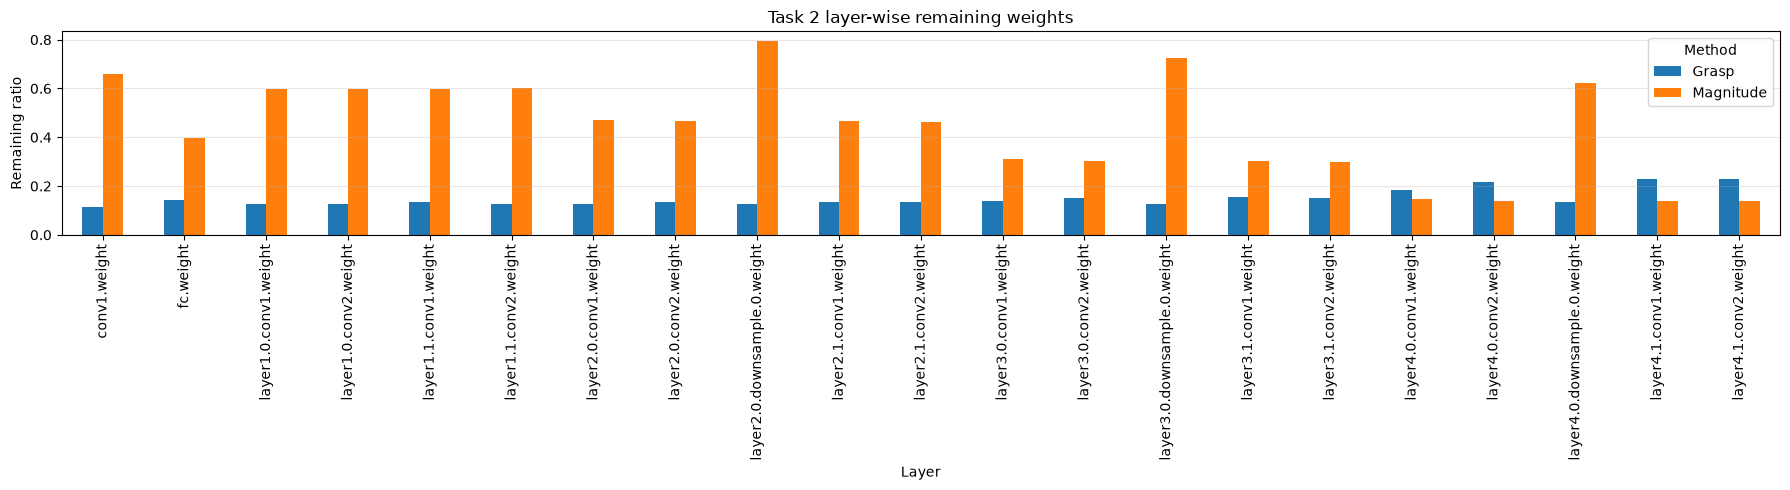

In [22]:
if TASK2_ACTIVE:
    method_runs = {
        "magnitude": (TASK2_MAG_MODEL, TASK2_MAG_MASKS, TASK2_MAG_HISTORY,
                      TASK2_MAG_STAGES, TASK2_MAG_TIMES),
        "grasp": (TASK2_GRASP_MODEL, TASK2_GRASP_MASKS, TASK2_GRASP_HISTORY,
                  TASK2_GRASP_STAGES, TASK2_GRASP_TIMES),
    }
    TASK2_OUTPUTS = {}
    remaining_rows = []
    for method, (model, masks, history, stages, criterion_times) in method_runs.items():
        print(f"Verifying, exporting, and profiling iterative {method}...", flush=True)
        apply_masks(model, masks)
        verification = verify_masks(model, masks)
        atomic_write_bytes(DIRS["results"] / f"task2_{method}_mask_verification.csv",
                           verification.to_csv(index=False).encode())
        final_metrics = stage_evaluation(model, TASK2_DATA)
        coo = export_coo(model, masks, f"task2_{method}_{int(TASK2_TARGET*100)}")
        dense_profile = profile_model(model, f"task2_{method}_{int(TASK2_TARGET*100)}")
        sparse_model = with_sparse_classifier(model).to(DEVICE)
        coo_profile = profile_model(
            sparse_model, f"task2_{method}_{int(TASK2_TARGET*100)}_coo_linear",
            stats_model=model)
        remaining_ratio = {key: 1.0 - value for key, value in layer_sparsities(masks).items()}
        for layer, ratio in remaining_ratio.items():
            remaining_rows.append({"Layer": layer, "Method": method.title(), "Remaining ratio": ratio})
        record = {
            "method": method, "initial_hash": TASK2_INITIAL_HASH,
            "target_sparsity": TASK2_TARGET, "overall_sparsity": mask_sparsity(masks),
            "layer_remaining_ratio": remaining_ratio, "stages": stages,
            "final": final_metrics, "criterion_times_seconds": criterion_times,
            "dense_weights_size_mb": serialized_size_mb(model),
            "dense_masked_size_mb": serialized_size_mb(model, masks), "coo": coo,
            "dense_kernel_macs": analytic_macs(model),
            "theoretical_nonzero_macs": nonzero_effective_macs(model),
            "profile": dense_profile, "coo_supported_profile": coo_profile,
        }
        atomic_write_json(DIRS["results"] / f"task2_{method}.json", record)
        TASK2_OUTPUTS[method] = record

    remaining_frame = pd.DataFrame(remaining_rows)
    remaining_pivot = remaining_frame.pivot(index="Layer", columns="Method", values="Remaining ratio")
    axis = remaining_pivot.plot.bar(figsize=(18, 5))
    axis.set(title="Task 2 layer-wise remaining weights", ylabel="Remaining ratio")
    axis.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "task2_layer_remaining.png", dpi=160, bbox_inches="tight")
    plt.show()
    TASK2_RESULT = {
        "config_hash": CONFIG_HASH, "target_sparsity": TASK2_TARGET,
        "calibration_samples": CONFIG.calibration_samples,
        "calibration_batch_size": CONFIG.calibration_batch_size,
        "calibration_batches": math.ceil(CONFIG.calibration_samples / CONFIG.calibration_batch_size),
        "calibration_indices_path": str(DIRS["results"] / "task2_calibration_indices.csv"),
        "initial_hash": TASK2_INITIAL_HASH, "methods": TASK2_OUTPUTS,
        "task1_global_reference": str(DIRS["results"] / f"task1_global_{int(TASK2_TARGET*100)}_result.json"),
    }
    atomic_write_json(DIRS["results"] / "task2.json", TASK2_RESULT)


### Task 2 Results: Saliency-Based Iterative Pruning

Both iterative methods started from the same random initialization and used the same **100-epoch budget** and **80% final sparsity**. The first warm-up epoch already reached **48.92% validation accuracy**, so the 20% target was crossed before the first epoch-level checkpoint.

| Method | Final Train Top-1 | Final Test Top-1 | Test Top-5 | Macro-F1 | Criterion time |
|---|---:|---:|---:|---:|---:|
| Iterative magnitude | 99.166% | 91.42% | 99.71% | 91.43% | 0.666 s |
| Iterative GraSP | 98.282% | 88.65% | 99.42% | 88.64% | 4.086 s |

**Pruning stages**

| Method | Stage sparsity | Test Top-1 before | Test Top-1 immediately after |
|---|---:|---:|---:|
| Magnitude | 40% | 47.91% | 46.70% |
| Magnitude | 60% | 61.75% | 57.34% |
| Magnitude | 80% | 65.13% | 43.88% |
| GraSP | 40% | 47.91% | 10.00% |
| GraSP | 60% | 46.88% | 11.87% |
| GraSP | 80% | 61.80% | 10.41% |

**Discussion**
- The Task 1 global magnitude model finished at **92.82%** test accuracy, while iterative magnitude finished at **91.42%**. This is only a reference comparison because Task 1 starts from a pretrained checkpoint while Task 2 starts from random weights.
- In this run, GraSP did **not** outperform iterative magnitude: **88.65% vs 91.42%** test Top-1.
- No layer collapsed completely. All layers retained some weights at the final 80% sparsity.




#### Task 2 final comparison

,Method,Final sparsity,Final train Top-1 (%),Final test Top-1 (%),Final train Top-5 (%),Final test Top-5 (%),Macro-F1 (%),Parameters,Dense weights (MB),COO total (MB),...,Theoretical nonzero MACs,Criterion time (s),Dense mean latency (ms),COO-path mean latency (ms),Average GPU memory (MB),Peak GPU memory (MB),CPU energy (J),GPU energy (J),CPU energy (J/image),GPU energy (J/image)
0,Magnitude,0.8,99.166,91.42,99.956,99.71,91.427425,11173962,44.770379,91.637649,...,54990048,0.665535,12.132291,12.274376,204.257280,338.464768,662.550977,1913.840399,0.001294,0.003738
1,Grasp,0.8,98.282,88.65,99.944,99.42,88.636637,11173962,44.770379,91.657785,...,21894819,4.086298,12.219479,12.284911,249.552384,383.759872,624.344044,1917.856471,0.001219,0.003746


#### Task 1 global magnitude reference (pretrained start)

,Method,Final sparsity,Final train Top-1 (%),Final test Top-1 (%),Final test Top-5 (%),Macro-F1 (%)
0,Task 1 global magnitude — pretrained reference,0.8,99.89,92.82,99.75,92.811142


#### Accuracy and sparsity before and after each stage

,Method,Stage,Epoch,Trigger,Target sparsity,Measured sparsity,Test Top-1 before (%),Test Top-1 after (%),Criterion time (s)
0,Magnitude,1,1,validation threshold,0.4,0.4,47.91,46.70,0.240293
1,Magnitude,2,2,validation accuracy threshold,0.6,0.6,61.75,57.34,0.227304
2,Magnitude,3,3,validation accuracy threshold,0.8,0.8,65.13,43.88,0.197938
3,Grasp,1,1,validation threshold,0.4,0.4,47.91,10.00,1.426761
4,Grasp,2,3,validation accuracy threshold,0.6,0.6,46.88,11.87,1.334309
5,Grasp,3,7,validation accuracy threshold,0.8,0.8,61.80,10.41,1.325228


#### Layer-wise remaining-weight ratio

Method,Grasp,Magnitude
Layer,,
conv1.weight,0.114583,0.657986
fc.weight,0.143555,0.398438
layer1.0.conv1.weight,0.126628,0.598579
layer1.0.conv2.weight,0.127062,0.597141
layer1.1.conv1.weight,0.133301,0.598117
layer1.1.conv2.weight,0.127441,0.602214
layer2.0.conv1.weight,0.127346,0.470079
layer2.0.conv2.weight,0.134318,0.466919
layer2.0.downsample.0.weight,0.125366,0.794556


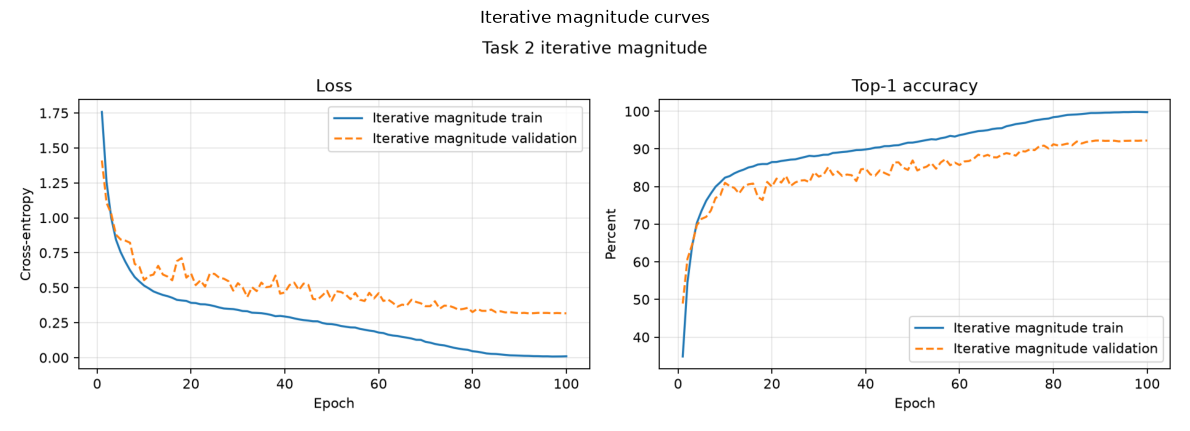

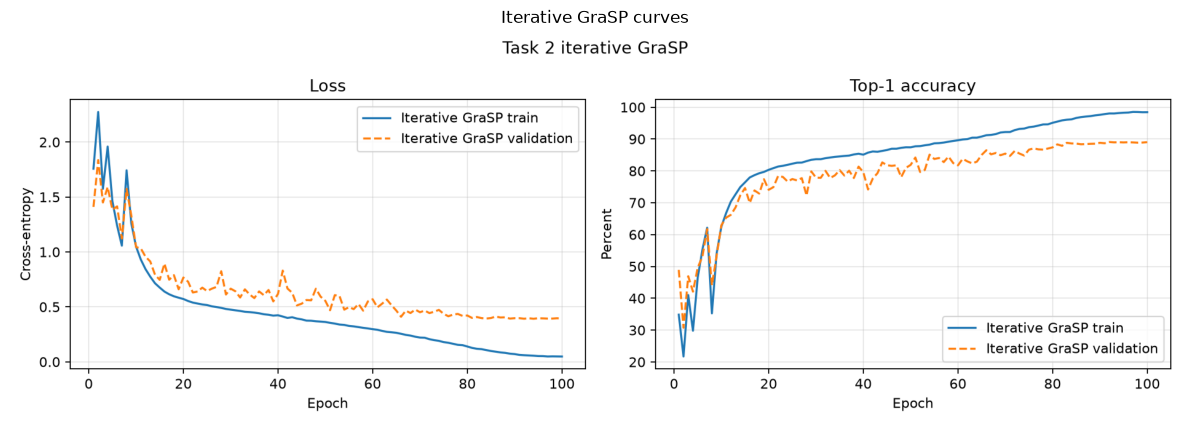

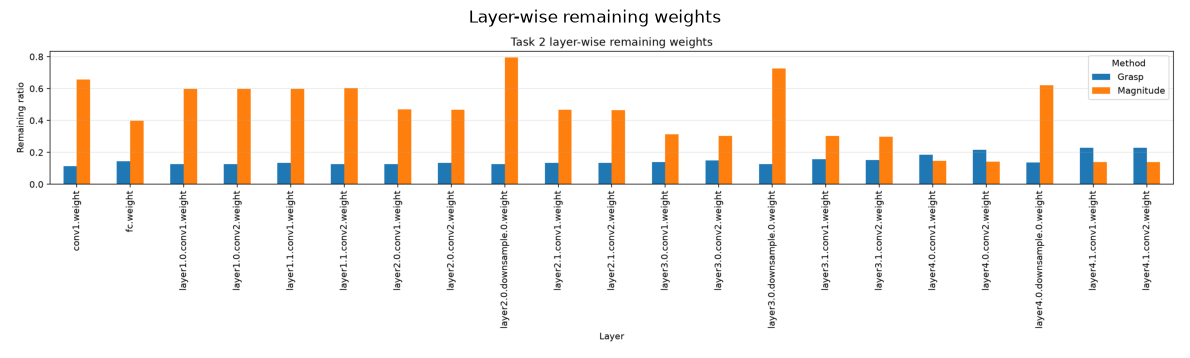


#### Task 2 discussion

Both methods used initialization hash **1f7b0761da53c6f0654eaa0d5bfde4ab84537d26890ffe3e9904662a17e2f758**.
GraSP finished with higher test accuracy than iterative magnitude: **False**.
Collapsed layers: **none**.
The Task 1 magnitude model is a pretrained reference. The fair controlled comparison is iterative magnitude against GraSP.


In [21]:
# Show Task 2 stage results, curves, layer ratios, and discussion here.
_task2_path = DIRS["results"] / "task2.json"
if _task2_path.exists():
    _task2 = json.loads(_task2_path.read_text())
    _summary, _stages, _remaining = [], [], []
    for _method, _item in _task2["methods"].items():
        _summary.append({
            "Method": _method.title(),
            "Final sparsity": _item["overall_sparsity"],
            "Final train Top-1 (%)": _item["final"]["train"]["top1"],
            "Final test Top-1 (%)": _item["final"]["test"]["top1"],
            "Final train Top-5 (%)": _item["final"]["train"]["top5"],
            "Final test Top-5 (%)": _item["final"]["test"]["top5"],
            "Macro-F1 (%)": _item["final"]["test"]["macro_f1"],
            "Parameters": _item["profile"]["parameters"],
            "Dense weights (MB)": _item["dense_weights_size_mb"],
            "COO total (MB)": _item["coo"]["size_mb"],
            "Executed MACs": _item["profile"]["macs"],
            "Executed FLOPs": _item["profile"]["flops"],
            "Theoretical nonzero MACs": _item["theoretical_nonzero_macs"],
            "Criterion time (s)": sum(_item["criterion_times_seconds"]),
            "Dense mean latency (ms)": _item["profile"]["latency_mean_batch_ms"],
            "COO-path mean latency (ms)": _item.get("coo_supported_profile", {}).get("latency_mean_batch_ms"),
            "Average GPU memory (MB)": _item["profile"]["gpu_memory_average_mb"],
            "Peak GPU memory (MB)": _item["profile"]["gpu_memory_peak_mb"],
            "CPU energy (J)": _item["profile"]["cpu_energy_j"],
            "GPU energy (J)": _item["profile"]["gpu_energy_j"],
            "CPU energy (J/image)": _item["profile"]["cpu_energy_j_per_image"],
            "GPU energy (J/image)": _item["profile"]["gpu_energy_j_per_image"],
        })
        for _stage in _item["stages"]:
            _stages.append({
                "Method": _method.title(),
                "Stage": _stage["stage"],
                "Epoch": _stage["epoch"],
                "Trigger": _stage["trigger_reason"],
                "Target sparsity": _stage["target_sparsity"],
                "Measured sparsity": _stage["measured_sparsity"],
                "Test Top-1 before (%)": _stage["before"]["test"]["top1"],
                "Test Top-1 after (%)": _stage["after"]["test"]["top1"],
                "Criterion time (s)": _stage["criterion_seconds"],
            })
        for _layer, _ratio in _item["layer_remaining_ratio"].items():
            _remaining.append({"Layer": _layer, "Method": _method.title(), "Remaining ratio": _ratio})
    display(Markdown("#### Task 2 final comparison"))
    display(pd.DataFrame(_summary))
    _task1_reference_path = Path(_task2["task1_global_reference"])
    if _task1_reference_path.exists():
        _reference = json.loads(_task1_reference_path.read_text())
        display(Markdown("#### Task 1 global magnitude reference (pretrained start)"))
        display(pd.DataFrame([{
            "Method": "Task 1 global magnitude — pretrained reference",
            "Final sparsity": _reference["overall_sparsity"],
            "Final train Top-1 (%)": _reference["post_finetune"]["full_train"]["top1"],
            "Final test Top-1 (%)": _reference["post_finetune"]["test"]["top1"],
            "Final test Top-5 (%)": _reference["post_finetune"]["test"]["top5"],
            "Macro-F1 (%)": _reference["post_finetune"]["test"]["macro_f1"],
        }]))
    display(Markdown("#### Accuracy and sparsity before and after each stage"))
    display(pd.DataFrame(_stages))
    display(Markdown("#### Layer-wise remaining-weight ratio"))
    display(pd.DataFrame(_remaining).pivot(index="Layer", columns="Method", values="Remaining ratio"))
    display_saved_figure(DIRS["figures"] / "task2_magnitude_training.png", "Iterative magnitude curves")
    display_saved_figure(DIRS["figures"] / "task2_grasp_training.png", "Iterative GraSP curves")
    display_saved_figure(DIRS["figures"] / "task2_layer_remaining.png", "Layer-wise remaining weights")
    _mag = _task2["methods"]["magnitude"]
    _grasp = _task2["methods"]["grasp"]
    _grasp_better = _grasp["final"]["test"]["top1"] > _mag["final"]["test"]["top1"]
    _collapsed = [
        _layer for _item in (_mag, _grasp)
        for _layer, _ratio in _item["layer_remaining_ratio"].items() if _ratio <= 0
    ]
    display(Markdown(f"""
#### Task 2 discussion

Both methods used initialization hash **{_task2['initial_hash']}**.
GraSP finished with higher test accuracy than iterative magnitude: **{_grasp_better}**.
Collapsed layers: **{_collapsed if _collapsed else 'none'}**.
The Task 1 magnitude model is a pretrained reference. The fair controlled comparison is iterative magnitude against GraSP.
"""))
else:
    display(Markdown("Task 2 is not complete. Run Task 2.1 through Task 2.5 above."))


## Task 3: Structured (Channel) Pruning — He et al., 2017

Regression-based channel pruning starting from the **Task 0 pretrained checkpoint**. Pruning begins at `layer1[1]`; stem and `layer1[0]` stay dense.


Pruning starts at `layer1[1]`. The stem and `layer1[0]` stay unchanged. Internal `conv1` outputs, matching `bn1` entries, and matching `conv2` inputs are removed while residual output widths stay unchanged.

$$
X_{\mathrm{unf}}\in\mathbb{R}^{(N\cdot L)\times(c\cdot k_h\cdot k_w)}
$$

$$
\widehat{\beta}=\arg\min_{\beta}\frac{1}{2N}\left\lVert Y-\sum_{i=1}^{c}\beta_iZ_i\right\rVert_F^2+\lambda\lVert\beta\rVert_1
$$


In [25]:
# Structured allocation, activation capture, LASSO, and reconstruction.
STRUCTURED_BLOCKS = [
    "layer1.1", "layer2.0", "layer2.1", "layer3.0",
    "layer3.1", "layer4.0", "layer4.1",
]


def module_by_path(model, path):
    value = model
    for part in path.split("."):
        value = value[int(part)] if part.isdigit() else getattr(value, part)
    return value


def sensitivity_score(frame, layer):
    group = frame[frame["layer"] == f"{layer}.conv2.weight"].sort_values("sparsity")
    if group.empty:
        return 1.0
    baseline = group[group["sparsity"] == 0]["test_top1"].max()
    drops = np.maximum(0, baseline - group["test_top1"].to_numpy())
    return float(np.trapezoid(drops, group["sparsity"].to_numpy()) + 1e-6)


def allocate_structured_widths(model, sensitivity_frame, target):
    dense_eligible = sum(parameter.numel() for _, parameter in eligible_named_parameters(model))
    target_removed = int(round(target * dense_eligible))
    widths = {path: module_by_path(model, path).conv1.out_channels for path in STRUCTURED_BLOCKS}
    original = dict(widths)
    scores = {path: sensitivity_score(sensitivity_frame, path) for path in STRUCTURED_BLOCKS}

    def saving_per_channel(path):
        block = module_by_path(model, path)
        kernel1 = block.conv1.kernel_size[0] * block.conv1.kernel_size[1]
        kernel2 = block.conv2.kernel_size[0] * block.conv2.kernel_size[1]
        return block.conv1.in_channels * kernel1 + block.conv2.out_channels * kernel2

    removed = 0
    while removed < target_removed:
        candidates = []
        for path in STRUCTURED_BLOCKS:
            if widths[path] <= CONFIG.structured_min_channels:
                continue
            step = 8 if widths[path] - 8 >= CONFIG.structured_min_channels and target_removed - removed >= 8 * saving_per_channel(path) else 1
            saving = step * saving_per_channel(path)
            fraction_removed = 1.0 - widths[path] / original[path]
            cost = scores[path] * (1.0 + fraction_removed) ** 2 / saving
            candidates.append((cost, path, step, saving))
        if not candidates:
            break
        _, path, step, saving = min(candidates, key=lambda item: (item[0], item[1]))
        if removed + saving > target_removed and abs(removed - target_removed) <= abs(removed + saving - target_removed):
            break
        widths[path] -= step
        removed += saving
    achieved = removed / dense_eligible
    if abs(achieved - target) > 0.005:
        raise RuntimeError(f"Structured allocation reached {achieved:.4f}, not within 0.5 points of {target:.4f}")
    return widths, {"dense_eligible": dense_eligible, "removed": removed, "achieved": achieved, "scores": scores}


@torch.inference_mode()
def capture_conv_pair(current_model, dense_target_model, block_path, loader):
    """Capture current inputs and target conv2 outputs from the original dense model."""
    current_block = module_by_path(current_model, block_path)
    target_block = module_by_path(dense_target_model, block_path)
    inputs, outputs = [], []

    def input_hook(module, args):
        inputs.append(args[0].detach().cpu())

    def output_hook(module, args, result):
        outputs.append(result.detach().cpu())

    input_handle = current_block.conv2.register_forward_pre_hook(input_hook)
    output_handle = target_block.conv2.register_forward_hook(output_hook)
    current_model.eval()
    dense_target_model.eval()
    for images, _ in loader:
        images = images.to(DEVICE)
        current_model(images)
        dense_target_model(images)
    input_handle.remove()
    output_handle.remove()
    return torch.cat(inputs), torch.cat(outputs)


def lasso_select_and_reconstruct(conv, inputs, outputs, keep_channels, seed):
    unfolded = F.unfold(inputs, kernel_size=conv.kernel_size, dilation=conv.dilation,
                        padding=conv.padding, stride=conv.stride)
    n, ck, locations = unfolded.shape
    channels, kernel_elements = conv.in_channels, ck // conv.in_channels
    windows = unfolded.transpose(1, 2).reshape(n * locations, channels, kernel_elements)
    response = outputs.permute(0, 2, 3, 1).reshape(n * locations, conv.out_channels)
    max_positions = max(1, CONFIG.structured_max_equations // conv.out_channels)
    if windows.shape[0] > max_positions:
        generator = torch.Generator().manual_seed(seed)
        positions = torch.randperm(windows.shape[0], generator=generator)[:max_positions]
        windows, response = windows[positions], response[positions]
    weights = conv.weight.detach().cpu().reshape(conv.out_channels, channels, kernel_elements).permute(1, 2, 0)
    contributions = torch.einsum("pck,cko->pco", windows, weights)
    lasso_x = contributions.reshape(-1, channels).numpy()
    lasso_y = response.reshape(-1).numpy()
    alpha_max = max(1e-8, float(np.max(np.abs(lasso_x.T @ lasso_y)) / len(lasso_y)))
    low, high, best = 0.0, alpha_max, None
    for _ in range(20):
        alpha = (low + high) / 2
        solver = Lasso(alpha=alpha, fit_intercept=False, max_iter=5000, selection="cyclic")
        solver.fit(lasso_x, lasso_y)
        beta = solver.coef_.astype(np.float32)
        active = int(np.count_nonzero(np.abs(beta) > 1e-10))
        candidate = (abs(active - keep_channels), beta, alpha, active)
        if best is None or candidate[0] < best[0]:
            best = candidate
        if active > keep_channels:
            low = alpha
        else:
            high = alpha
    beta = best[1]
    selected = np.sort(np.argsort(np.abs(beta))[-keep_channels:])
    selected_beta = beta[selected]
    selected_beta[np.abs(selected_beta) < 1e-10] = 1.0
    reduced = windows[:, selected, :] * torch.from_numpy(selected_beta)[None, :, None]
    solution = torch.linalg.lstsq(reduced.reshape(reduced.shape[0], -1).float(), response.float()).solution
    reconstructed = solution.T.reshape(conv.out_channels, keep_channels, *conv.kernel_size)
    reconstructed = reconstructed * torch.from_numpy(selected_beta)[None, :, None, None]
    predicted = F.conv2d(inputs[:, selected], reconstructed, None, conv.stride,
                         conv.padding, conv.dilation, conv.groups)
    relative_error = (predicted - outputs).norm().item() / max(outputs.norm().item(), 1e-12)
    return selected.tolist(), reconstructed, {
        "input_shape": list(inputs.shape), "unfolded_shape": list(unfolded.shape),
        "output_shape": list(outputs.shape), "equations": int(lasso_x.shape[0]),
        "lasso_alpha": float(best[2]), "lasso_nonzero_before_exact_selection": int(best[3]),
        "relative_reconstruction_error": relative_error,
        "target_output_source": "original dense checkpoint",
    }


def replace_block_internal_channels(block, selected, reconstructed=None):
    selected_tensor = torch.as_tensor(selected, dtype=torch.long)
    old_conv1, old_bn1, old_conv2 = block.conv1, block.bn1, block.conv2
    keep = len(selected)
    new_conv1 = nn.Conv2d(old_conv1.in_channels, keep, old_conv1.kernel_size,
                          old_conv1.stride, old_conv1.padding, old_conv1.dilation,
                          old_conv1.groups, bias=False)
    new_bn1 = nn.BatchNorm2d(keep, eps=old_bn1.eps, momentum=old_bn1.momentum,
                             affine=old_bn1.affine, track_running_stats=old_bn1.track_running_stats)
    new_conv2 = nn.Conv2d(keep, old_conv2.out_channels, old_conv2.kernel_size,
                          old_conv2.stride, old_conv2.padding, old_conv2.dilation,
                          old_conv2.groups, bias=False)
    with torch.no_grad():
        new_conv1.weight.copy_(old_conv1.weight.detach().cpu()[selected_tensor])
        if old_bn1.affine:
            new_bn1.weight.copy_(old_bn1.weight.detach().cpu()[selected_tensor])
            new_bn1.bias.copy_(old_bn1.bias.detach().cpu()[selected_tensor])
        if old_bn1.track_running_stats:
            new_bn1.running_mean.copy_(old_bn1.running_mean.detach().cpu()[selected_tensor])
            new_bn1.running_var.copy_(old_bn1.running_var.detach().cpu()[selected_tensor])
            new_bn1.num_batches_tracked.copy_(old_bn1.num_batches_tracked.detach().cpu())
        source = old_conv2.weight.detach().cpu()[:, selected_tensor] if reconstructed is None else reconstructed
        new_conv2.weight.copy_(source)
    block.conv1, block.bn1, block.conv2 = new_conv1, new_bn1, new_conv2


def rebuild_structured_model(spec):
    model = resnet18(pretrained=False)
    for item in spec:
        replace_block_internal_channels(module_by_path(model, item["block"]),
                                        list(range(int(item["keep_channels"]))), None)
    return model


def run_structured_pruning(data, target):
    sensitivity = pd.read_json(DIRS["results"] / "task1_sensitivity.json")
    manager = CheckpointManager("task3_structured_pruning")
    saved = manager.load()
    rows, spec, completed = [], [], set()
    if saved:
        spec, rows = saved["extra"]["spec"], saved["extra"]["rows"]
        completed = {item["block"] for item in spec}
        model = rebuild_structured_model(spec).to(DEVICE)
        model.load_state_dict(saved["model_state"], strict=True)
        if saved["phase"] == "complete":
            return model, spec, rows, saved["extra"]["allocation"]
    else:
        model = resnet18(pretrained=True).to(DEVICE)
    allocation_model = resnet18(pretrained=True).to(DEVICE)
    widths, allocation = allocate_structured_widths(allocation_model, sensitivity, target)
    loader = calibration_loader(data)
    dense_target_model = resnet18(pretrained=True).to(DEVICE).eval()

    for index, block_path in enumerate(STRUCTURED_BLOCKS):
        if block_path in completed:
            continue
        manager.save({
            "task": "task3", "phase": f"before_{block_path}",
            "model_state": cpu_model_state(model), "rng_state": get_rng_state(),
            "extra": {"spec": spec, "rows": rows, "allocation": allocation},
        }, milestone=f"before_layer_{index+1}_{block_path.replace('.', '_')}")
        inputs, outputs = capture_conv_pair(model, dense_target_model, block_path, loader)
        block = module_by_path(model, block_path)
        block.conv2.cpu()
        selected, reconstructed, details = lasso_select_and_reconstruct(
            block.conv2, inputs, outputs, widths[block_path], CONFIG.seed + index)
        replace_block_internal_channels(block, selected, reconstructed)
        model.to(DEVICE)
        with torch.inference_mode():
            if model(torch.zeros(2, 3, 32, 32, device=DEVICE)).shape != (2, 10):
                raise AssertionError(f"Structured model failed after {block_path}")
        spec.append({"block": block_path, "keep_channels": len(selected), "selected": selected})
        rows.append({"block": block_path, "original_channels": inputs.shape[1],
                     "kept_channels": len(selected), **details})
        manager.save({
            "task": "task3", "phase": "structured_pruning",
            "model_state": cpu_model_state(model), "rng_state": get_rng_state(),
            "extra": {"spec": spec, "rows": rows, "allocation": allocation},
        }, milestone=f"layer_{index+1}_{block_path.replace('.', '_')}")
        atomic_write_json(DIRS["results"] / "task3_reconstruction.json", rows)
        print(
            f"[{block_path}] {inputs.shape[1]} -> {len(selected)} channels | "
            f"unfolded {details['unfolded_shape']} | "
            f"relative reconstruction error {details['relative_reconstruction_error']:.6f}",
            flush=True,
        )
        if STOP_REQUESTED.is_set():
            return model, spec, rows, allocation

    dense_count = sum(p.numel() for _, p in eligible_named_parameters(resnet18()))
    structured_count = sum(p.numel() for _, p in eligible_named_parameters(model))
    actual_reduction = 1.0 - structured_count / dense_count
    if abs(actual_reduction - target) > 0.005:
        raise AssertionError(f"Actual structured reduction {actual_reduction:.4f} misses target {target:.4f}")
    allocation["actual_reduction"] = actual_reduction
    manager.save({
        "task": "task3", "phase": "complete", "model_state": cpu_model_state(model),
        "rng_state": get_rng_state(),
        "extra": {"spec": spec, "rows": rows, "allocation": allocation},
    }, milestone="complete")
    return model, spec, rows, allocation


### Task 3.1 — Allocate the structured channel budget

This cell uses Task 1 sensitivity, keeps at least eight channels per block, prefers multiples of eight, and verifies the planned reduction is within 0.5 percentage points of the selected target.


In [34]:
TASK3_ACTIVE = task_enabled("task3")
if TASK3_ACTIVE:
    task1_path = DIRS["results"] / "task1.json"
    if not task1_path.exists():
        raise RuntimeError("Complete Task 1 before Task 3")
    task1_result = json.loads(task1_path.read_text())
    if task1_result.get("config_hash") != CONFIG_HASH:
        raise RuntimeError("Task 1 results use a different configuration")
    TASK3_TARGET = float(task1_result["selected_target_sparsity"])
    TASK3_DATA = load_data()
    TASK3_SENSITIVITY = pd.read_json(DIRS["results"] / "task1_sensitivity.json")
    allocation_model = resnet18(pretrained=True).to(DEVICE)
    TASK3_WIDTHS, TASK3_ALLOCATION_PREVIEW = allocate_structured_widths(
        allocation_model, TASK3_SENSITIVITY, TASK3_TARGET)
    display(pd.DataFrame([{
        "Block": block, "Original channels": module_by_path(allocation_model, block).conv1.out_channels,
        "Kept channels": TASK3_WIDTHS[block],
        "Sensitivity score": TASK3_ALLOCATION_PREVIEW["scores"][block],
    } for block in STRUCTURED_BLOCKS]))
    display(pd.DataFrame([{
        "Target reduction": TASK3_TARGET,
        "Planned reduction": TASK3_ALLOCATION_PREVIEW["achieved"],
        "Difference (percentage points)": 100 * abs(TASK3_ALLOCATION_PREVIEW["achieved"] - TASK3_TARGET),
    }]))
else:
    print("Task 3 execution is skipped for this RUN_TASK value.")


,Block,Original channels,Kept channels,Sensitivity score
0,layer1.1,64,64,0.182001
1,layer2.0,128,128,0.497501
2,layer2.1,128,128,0.350501
3,layer3.0,256,248,0.201001
4,layer3.1,256,88,0.063501
5,layer4.0,512,8,0.004001
6,layer4.1,512,8,0.000001


,Target reduction,Planned reduction,Difference (percentage points)
0,0.8,0.799895,0.010548


### Task 3.2 — Select channels and reconstruct each block

Each block prints its input and unfolded shapes, channel count, and reconstruction error. A checkpoint is saved before and after every block.


In [35]:
if TASK3_ACTIVE:
    clear_stop_if_resuming()
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming Task 3 pruning.")
        STOP_REQUESTED.clear()
    TASK3_MODEL, TASK3_SPEC, TASK3_ROWS, TASK3_ALLOCATION = run_structured_pruning(
        TASK3_DATA, TASK3_TARGET)
    if STOP_REQUESTED.is_set():
        raise RuntimeError("Structured pruning stopped after a safe layer checkpoint; rerun this cell")
    display(pd.DataFrame(TASK3_ROWS))


/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.703854e-03, tolerance: 6.830e-04
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.811241e-02, tolerance: 6.830e-04
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[layer1.1] 64 -> 64 channels | unfolded [1024, 576, 256] | relative reconstruction error 0.000112


/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.792213e-03, tolerance: 1.915e-03
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.132679e-02, tolerance: 1.915e-03
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[layer2.0] 128 -> 128 channels | unfolded [1024, 1152, 64] | relative reconstruction error 0.337986


/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.140594e-03, tolerance: 5.544e-04
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.988909e-03, tolerance: 5.544e-04
  model = cd_fast.enet_coordinate_descent(
/home/dksg/AIEJ/AIED/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duali

[layer2.1] 128 -> 128 channels | unfolded [1024, 1152, 64] | relative reconstruction error 0.509103
[layer3.0] 256 -> 248 channels | unfolded [1024, 2304, 16] | relative reconstruction error 0.522724
[layer3.1] 256 -> 88 channels | unfolded [1024, 2304, 16] | relative reconstruction error 0.445059
[layer4.0] 512 -> 8 channels | unfolded [1024, 4608, 4] | relative reconstruction error 0.656267
[layer4.1] 512 -> 8 channels | unfolded [1024, 4608, 4] | relative reconstruction error 0.693041


,block,original_channels,kept_channels,input_shape,unfolded_shape,output_shape,equations,lasso_alpha,lasso_nonzero_before_exact_selection,relative_reconstruction_error,target_output_source
0,layer1.1,64,64,"[1024, 64, 16, 16]","[1024, 576, 256]","[1024, 64, 16, 16]",200000,1.030222e-09,64,0.000112,original dense checkpoint
1,layer2.0,128,128,"[1024, 128, 8, 8]","[1024, 1152, 64]","[1024, 128, 8, 8]",199936,3.002676e-10,128,0.337986,original dense checkpoint
2,layer2.1,128,128,"[1024, 128, 8, 8]","[1024, 1152, 64]","[1024, 128, 8, 8]",199936,2.038750e-11,128,0.509103,original dense checkpoint
3,layer3.0,256,248,"[1024, 256, 4, 4]","[1024, 2304, 16]","[1024, 256, 4, 4]",199936,5.730251e-11,248,0.522724,original dense checkpoint
4,layer3.1,256,88,"[1024, 256, 4, 4]","[1024, 2304, 16]","[1024, 256, 4, 4]",199936,8.249939e-10,88,0.445059,original dense checkpoint
5,layer4.0,512,8,"[1024, 512, 2, 2]","[1024, 4608, 4]","[1024, 512, 2, 2]",199680,2.736045e-09,8,0.656267,original dense checkpoint
6,layer4.1,512,8,"[1024, 512, 2, 2]","[1024, 4608, 4]","[1024, 512, 2, 2]",199680,2.620654e-09,8,0.693041,original dense checkpoint


### Task 3.3 — Fine-tune the physically smaller model

This cell records metrics before fine-tuning and prints all 20 training epochs.


evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

[task3_finetune_80] epoch 001/020 | train loss 0.2320 | train Top-1 93.83% | validation loss 0.2496 | validation Top-1 92.34%


...

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

[task3_finetune_80] epoch 020/020 | train loss 0.0230 | train Top-1 99.56% | validation loss 0.0886 | validation Top-1 97.28%


evaluate:   0%|          | 0/196 [00:00<?, ?it/s]

evaluate:   0%|          | 0/20 [00:00<?, ?it/s]

evaluate:   0%|          | 0/40 [00:00<?, ?it/s]

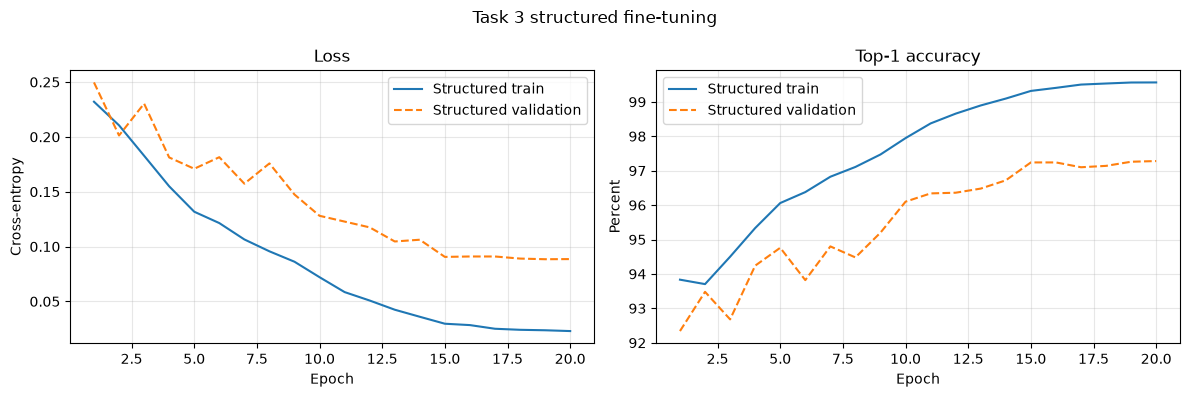

,Test Top-1 before (%),Test Top-1 after (%),Test Top-5 after (%),Macro-F1 after (%)
0,87.27,92.61,99.72,92.606399


In [36]:
if TASK3_ACTIVE:
    clear_stop_if_resuming()
    if STOP_REQUESTED.is_set():
        print("Clearing the previous handled stop request before resuming Task 3 fine-tuning.")
        STOP_REQUESTED.clear()
    TASK3_PRE_FINETUNE = stage_evaluation(TASK3_MODEL, TASK3_DATA)
    TASK3_TRAINED = train_model(
        TASK3_MODEL, TASK3_DATA, f"task3_finetune_{int(TASK3_TARGET*100)}", "task3",
        CONFIG.task3_epochs, CONFIG.fine_tune_lr, masks=None,
        extra={"structured_spec": TASK3_SPEC, "allocation": TASK3_ALLOCATION})
    if TASK3_TRAINED["interrupted"]:
        raise RuntimeError("Task 3 fine-tuning stopped after a safe checkpoint; rerun this cell")
    TASK3_MODEL = TASK3_TRAINED["model"]
    TASK3_POST_FINETUNE = stage_evaluation(TASK3_MODEL, TASK3_DATA)
    plot_history({"Structured": TASK3_TRAINED["history"]},
                 DIRS["figures"] / "task3_training.png",
                 "Task 3 structured fine-tuning")
    display(pd.DataFrame([{
        "Test Top-1 before (%)": TASK3_PRE_FINETUNE["test"]["top1"],
        "Test Top-1 after (%)": TASK3_POST_FINETUNE["test"]["top1"],
        "Test Top-5 after (%)": TASK3_POST_FINETUNE["test"]["top5"],
        "Macro-F1 after (%)": TASK3_POST_FINETUNE["test"]["macro_f1"],
    }]))


### Task 3.4 — Profile and save Task 3

This cell profiles the final dense structured tensors and writes the Task 3 result table.


In [37]:
if TASK3_ACTIVE:
    TASK3_MACS = analytic_macs(TASK3_MODEL)
    TASK3_RESULT = {
        "config_hash": CONFIG_HASH, "method": "structured_regression",
        "target_sparsity": TASK3_TARGET,
        "parameter_reduction": TASK3_ALLOCATION["actual_reduction"],
        "structured_spec": TASK3_SPEC, "reconstruction": TASK3_ROWS,
        "pre_finetune": TASK3_PRE_FINETUNE, "post_finetune": TASK3_POST_FINETUNE,
        "parameters": sum(parameter.numel() for parameter in TASK3_MODEL.parameters()),
        "serialized_size_mb": serialized_size_mb(TASK3_MODEL),
        "macs": TASK3_MACS, "flops": 2 * TASK3_MACS,
        "history": TASK3_TRAINED["history"],
    }
    atomic_write_json(DIRS["results"] / "task3.json", TASK3_RESULT)
    print("Starting the common structured-model profile...", flush=True)
    TASK3_RESULT["profile"] = profile_model(
        TASK3_MODEL, f"task3_structured_{int(TASK3_TARGET*100)}")
    atomic_write_json(DIRS["results"] / "task3.json", TASK3_RESULT)
    display(pd.DataFrame([{
        "Measured eligible-weight reduction": TASK3_RESULT["parameter_reduction"],
        "Parameters": TASK3_RESULT["parameters"], "Serialized size (MB)": TASK3_RESULT["serialized_size_mb"],
        "MACs": TASK3_RESULT["macs"], "FLOPs": TASK3_RESULT["flops"],
        "Mean latency (ms)": TASK3_RESULT["profile"]["latency_mean_batch_ms"],
    }]))


Starting the common structured-model profile...


,Measured eligible-weight reduction,Parameters,Serialized size (MB),MACs,FLOPs,Mean latency (ms)
0,0.799895,2241290,9.029643,94843904,189687808,9.901775


### Task 3 Results: Regression-Based Channel Pruning

The structured model reached **79.99% parameter reduction** and was fine-tuned for 20 epochs.

| Metric | Dense baseline | Structured model |
|---|---:|---:|
| Test Top-1 | 93.07% | 92.61% |
| Test Top-5 | 99.74% | 99.72% |
| Macro-F1 | 93.07% | 92.61% |
| Parameters | 11,173,962 | 2,241,290 |
| Model size | 44.77 MB | 9.03 MB |
| MACs | 140.19 M | 94.84 M |
| FLOPs | 280.37 M | 189.69 M |
| Mean latency | 12.00 ms | 9.90 ms |
| Average GPU memory | 57.48 MB | 786.13 MB |
| Peak GPU memory | 191.68 MB | 920.34 MB |
| CPU energy | 0.002245 J/image | 0.001022 J/image |
| GPU energy | 0.003683 J/image | 0.003030 J/image |

**Discussion**
- The final accuracy drop was only **0.46 percentage points**, so the accuracy constraint was met.
- Model size decreased by about **79.8%**, MACs decreased by about **32.3%**, and mean latency improved by about **17.5%**.
- The measured GPU memory did **not** improve in this profiling run. Peak memory increased even though the parameter count was much smaller. Peak runtime memory also depends on activations, allocator/caching behavior, and profiling overhead, not only the number of model parameters.
- The implementation removes internal `conv1` output channels together with the matching `bn1` entries and `conv2` input channels. Residual block output widths stay unchanged, so the shortcut output dimensions remain compatible.


#### Structured layer reconstruction

,block,original_channels,kept_channels,input_shape,unfolded_shape,output_shape,equations,lasso_alpha,lasso_nonzero_before_exact_selection,relative_reconstruction_error,target_output_source
0,layer1.1,64,64,"[1024, 64, 16, 16]","[1024, 576, 256]","[1024, 64, 16, 16]",200000,1.030222e-09,64,0.000112,original dense checkpoint
1,layer2.0,128,128,"[1024, 128, 8, 8]","[1024, 1152, 64]","[1024, 128, 8, 8]",199936,3.002676e-10,128,0.337986,original dense checkpoint
2,layer2.1,128,128,"[1024, 128, 8, 8]","[1024, 1152, 64]","[1024, 128, 8, 8]",199936,2.038750e-11,128,0.509103,original dense checkpoint
3,layer3.0,256,248,"[1024, 256, 4, 4]","[1024, 2304, 16]","[1024, 256, 4, 4]",199936,5.730251e-11,248,0.522724,original dense checkpoint
4,layer3.1,256,88,"[1024, 256, 4, 4]","[1024, 2304, 16]","[1024, 256, 4, 4]",199936,8.249939e-10,88,0.445059,original dense checkpoint
5,layer4.0,512,8,"[1024, 512, 2, 2]","[1024, 4608, 4]","[1024, 512, 2, 2]",199680,2.736045e-09,8,0.656267,original dense checkpoint
6,layer4.1,512,8,"[1024, 512, 2, 2]","[1024, 4608, 4]","[1024, 512, 2, 2]",199680,2.620654e-09,8,0.693041,original dense checkpoint


#### Task 3 final results

,Target reduction,Measured parameter reduction,Train Top-1 (%),Test Top-1 before fine-tuning (%),Test Top-1 after fine-tuning (%),Test Top-5 (%),Macro-F1 (%),Parameters,Model size (MB),MACs,FLOPs,Mean latency (ms),Average GPU memory (MB),Peak GPU memory (MB),"Average device memory (MB, NVML)","Peak device memory (MB, NVML)",CPU energy (J),GPU energy (J),CPU energy (J/image),GPU energy (J/image)
0,0.8,0.799895,99.552,87.27,92.61,99.72,92.606399,2241290,9.029643,94843904,189687808,9.901775,786.131968,920.339456,1742.798848,1742.798848,523.429935,1551.241062,0.001022,0.00303


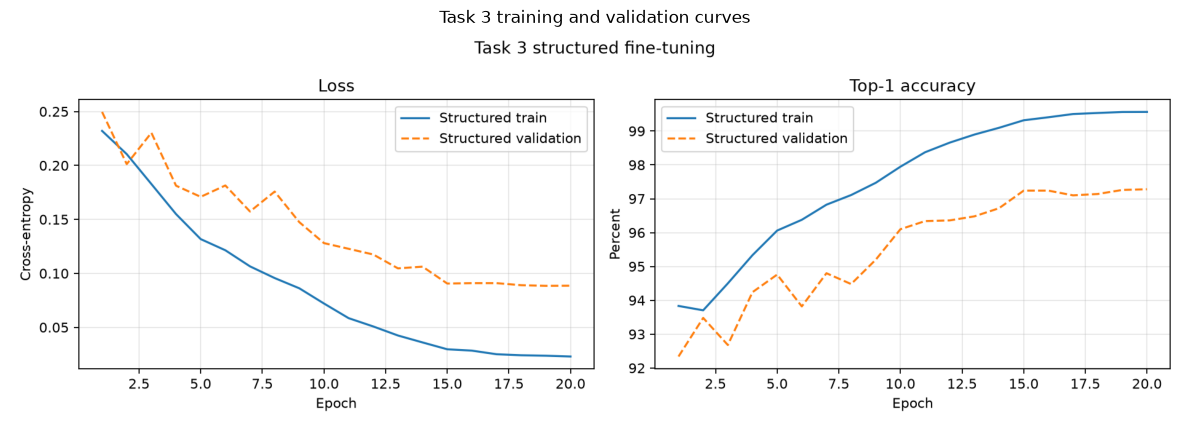


#### Task 3 discussion

The test accuracy drop is **0.46 percentage points**.
Peak GPU memory improved: **False**.
Mean latency improved: **True**.
Physical channel removal reduces tensor dimensions and MACs. Speed may improve by a smaller amount because of kernel overhead, memory movement, and GPU utilization.


In [38]:
# Show Task 3 channel choices, reconstruction, curves, profile, and discussion here.
_task3_path = DIRS["results"] / "task3.json"
if _task3_path.exists():
    _task3 = json.loads(_task3_path.read_text())
    display(Markdown("#### Structured layer reconstruction"))
    display(pd.DataFrame(_task3["reconstruction"]))
    _profile = _task3["profile"]
    display(Markdown("#### Task 3 final results"))
    display(pd.DataFrame([{
        "Target reduction": _task3["target_sparsity"],
        "Measured parameter reduction": _task3["parameter_reduction"],
        "Train Top-1 (%)": _task3["post_finetune"]["train"]["top1"],
        "Test Top-1 before fine-tuning (%)": _task3["pre_finetune"]["test"]["top1"],
        "Test Top-1 after fine-tuning (%)": _task3["post_finetune"]["test"]["top1"],
        "Test Top-5 (%)": _task3["post_finetune"]["test"]["top5"],
        "Macro-F1 (%)": _task3["post_finetune"]["test"]["macro_f1"],
        "Parameters": _task3["parameters"],
        "Model size (MB)": _task3["serialized_size_mb"],
        "MACs": _task3["macs"],
        "FLOPs": _task3["flops"],
        "Mean latency (ms)": _profile["latency_mean_batch_ms"],
        "Average GPU memory (MB)": _profile["gpu_memory_average_mb"],
        "Peak GPU memory (MB)": _profile["gpu_memory_peak_mb"],
        "Average device memory (MB, NVML)": _profile.get("gpu_device_memory_average_mb"),
        "Peak device memory (MB, NVML)": _profile.get("gpu_device_memory_peak_mb"),
        "CPU energy (J)": _profile["cpu_energy_j"],
        "GPU energy (J)": _profile["gpu_energy_j"],
        "CPU energy (J/image)": _profile["cpu_energy_j_per_image"],
        "GPU energy (J/image)": _profile["gpu_energy_j_per_image"],
    }]))
    display_saved_figure(DIRS["figures"] / "task3_training.png", "Task 3 training and validation curves")
    _dense = json.loads((DIRS["results"] / "task0.json").read_text())
    _drop = _dense["evaluations"]["test"]["top1"] - _task3["post_finetune"]["test"]["top1"]
    _memory_better = _profile["gpu_memory_peak_mb"] < _dense["profile"]["gpu_memory_peak_mb"]
    _latency_better = _profile["latency_mean_batch_ms"] < _dense["profile"]["latency_mean_batch_ms"]
    display(Markdown(f"""
#### Task 3 discussion

The test accuracy drop is **{_drop:.2f} percentage points**.
Peak GPU memory improved: **{_memory_better}**.
Mean latency improved: **{_latency_better}**.
Physical channel removal reduces tensor dimensions and MACs. Speed may improve by a smaller amount because of kernel overhead, memory movement, and GPU utilization.
"""))
else:
    display(Markdown("Task 3 is not complete. Run Task 3.1 through Task 3.4 above."))


## Final Report

The detailed tables below summarize all recorded experiments.

### Main comparison

| Model | Test Top-1 | Test Top-5 | Macro-F1 | Sparsity / reduction |
|---|---:|---:|---:|---:|
| Dense FP32 | 93.07% | 99.74% | 93.07% | 0% |
| Task 1 Local magnitude | 92.99% | 99.77% | 92.99% | 80% |
| Task 1 Global magnitude | 92.82% | 99.75% | 92.81% | 80% |
| Task 2 Iterative magnitude | 91.42% | 99.71% | 91.43% | 80% |
| Task 2 Iterative GraSP* | 88.65% | 99.42% | 88.64% | 80% |
| Task 3 Structured regression | 92.61% | 99.72% | 92.61% | 79.99% |



In [12]:
# Final tables and simple-English discussions.
def load_required_json(name):
    path = DIRS["results"] / name
    if not path.exists():
        raise FileNotFoundError(f"Required result is missing: {path}")
    return json.loads(path.read_text())


def common_result_row(label, metrics, profile, extra=None):
    extra = {} if extra is None else extra
    return {
        "Model": label,
        "Train Top-1 (%)": metrics.get("full_train", metrics.get("train", {})).get("top1"),
        "Test Top-1 (%)": metrics["test"]["top1"],
        "Train Top-5 (%)": metrics.get("full_train", metrics.get("train", {})).get("top5"),
        "Test Top-5 (%)": metrics["test"]["top5"],
        "Macro-F1 (%)": metrics["test"]["macro_f1"],
        "Parameters": profile.get("parameters"),
        "Serialized size (MB)": profile.get("serialized_size_mb"),
        "MACs": profile.get("macs"),
        "FLOPs": profile.get("flops"),
        "Mean batch latency (ms)": profile.get("latency_mean_batch_ms"),
        "Mean image latency (ms)": profile.get("latency_mean_image_ms"),
        "Peak GPU memory (MB)": profile.get("gpu_memory_peak_mb"),
        "Average GPU memory (MB)": profile.get("gpu_memory_average_mb"),
        "CPU energy (J)": profile.get("cpu_energy_j"),
        "GPU energy (J)": profile.get("gpu_energy_j"),
        "CPU energy (J/image)": profile.get("cpu_energy_j_per_image"),
        "GPU energy (J/image)": profile.get("gpu_energy_j_per_image"),
        **extra,
    }


In [27]:
def run_report():
    task0 = load_required_json("task0.json")
    task1 = load_required_json("task1.json")
    task2 = load_required_json("task2.json")
    task3 = load_required_json("task3.json")
    display(Markdown("### Environment and reproducibility"))
    environment = task0.get("environment", {})
    display(pd.DataFrame([{
        "Python": environment.get("python"), "Platform": environment.get("platform"),
        "PyTorch": environment.get("torch"), "torchvision": environment.get("torchvision"),
        "CUDA runtime": environment.get("cuda_runtime"), "GPU": environment.get("gpu"),
        "Seed": environment.get("config", {}).get("seed"),
        "Batch size": environment.get("config", {}).get("batch_size"),
        "Configuration hash": environment.get("config_hash"),
        "Checkpoint SHA-256": task0.get("weights_sha256"),
    }]))
    rows = [common_result_row("Dense FP32", task0["evaluations"], task0["profile"],
                              {"Sparsity / reduction": 0.0})]
    for method in ("local", "global"):
        item = task1["methods"][method]
        rows.append(common_result_row(
            f"Task 1 {method.title()} magnitude", item["post_finetune"], item["dense_profile"],
            {"Sparsity / reduction": item["overall_sparsity"], "COO size (MB)": item["coo"]["size_mb"]}))
    for method in ("magnitude", "grasp"):
        item = task2["methods"][method]
        rows.append(common_result_row(
            f"Task 2 Iterative {method.title()}", item["final"], item["profile"],
            {"Sparsity / reduction": item["overall_sparsity"],
             "COO size (MB)": item["coo"]["size_mb"],
             "Criterion time (s)": sum(item["criterion_times_seconds"])}))
    rows.append(common_result_row(
        "Task 3 Structured regression", task3["post_finetune"], task3["profile"],
        {"Sparsity / reduction": task3["parameter_reduction"]}))
    comparison = pd.DataFrame(rows)
    atomic_write_bytes(DIRS["results"] / "final_comparison.csv", comparison.to_csv(index=False).encode())
    display(Markdown("### Final comparison"))
    display(comparison)

    sensitivity = pd.read_json(DIRS["results"] / "task1_sensitivity.json")
    dense_acc = task0["evaluations"]["test"]["top1"]
    loss90 = sensitivity[sensitivity["sparsity"] == 0.90].copy()
    loss90["drop"] = dense_acc - loss90["test_top1"]
    most_sensitive = loss90.sort_values("drop", ascending=False).iloc[0]["layer"]
    global_item = task1["methods"]["global"]
    global_reasonable = max(global_item["layer_sparsity"].values()) < 1.0
    local_item = task1["methods"]["local"]
    coo_reduced = local_item["coo"]["size_mb"] < local_item["dense_masked_size_mb"]
    

    magnitude, grasp = task2["methods"]["magnitude"], task2["methods"]["grasp"]
    grasp_better = grasp["final"]["test"]["top1"] > magnitude["final"]["test"]["top1"]
    collapsed = [name for method in (magnitude, grasp)
                 for name, ratio in method["layer_remaining_ratio"].items() if ratio <= 0]
    

    dense_profile, structured_profile = task0["profile"], task3["profile"]
    memory_improved = structured_profile["gpu_memory_peak_mb"] < dense_profile["gpu_memory_peak_mb"]
    latency_improved = structured_profile["latency_mean_batch_ms"] < dense_profile["latency_mean_batch_ms"]
    accuracy_drop = dense_acc - task3["post_finetune"]["test"]["top1"]
   

    audit = [
        ("Task 0 train/test Top-1, Top-5, macro-F1", True),
        ("Task 0 parameters, size, MACs, FLOPs", True),
        ("Common latency, memory, CPU energy, GPU energy", all(pd.notna(comparison[c]).all() for c in [
            "Mean batch latency (ms)", "Peak GPU memory (MB)", "Average GPU memory (MB)",
            "CPU energy (J)", "GPU energy (J)"])),
        ("Task 1 all-layer sensitivity curves", (DIRS["figures"] / "task1_sensitivity.png").exists()),
        ("Task 1 local/global sparsity and mask checks", True),
        ("Task 1 dense and COO storage", True),
        ("Task 1 fine-tuning curves and discussion", True),
        ("Task 2 three stages and criterion times", all(len(task2["methods"][m]["stages"]) == 3 for m in ("magnitude", "grasp"))),
        ("Task 2 shared initialization and budget", task2["methods"]["magnitude"]["initial_hash"] == task2["methods"]["grasp"]["initial_hash"]),
        ("Task 2 curves and remaining-weight ratios", True),
        ("Task 3 LASSO and least-squares reconstruction", len(task3["reconstruction"]) == len(STRUCTURED_BLOCKS)),
        ("Task 3 physical model and fine-tuning", True),
        ("Final comparison and simple discussion", True),
    ]
    audit_frame = pd.DataFrame(audit, columns=["Deliverable", "Complete"])
    atomic_write_bytes(DIRS["results"] / "deliverable_audit.csv", audit_frame.to_csv(index=False).encode())
    display(Markdown("### Deliverable audit"))
    display(audit_frame)
    if not audit_frame["Complete"].all():
        raise RuntimeError("The deliverable audit contains incomplete items")

    report_path = ROOT / "PA2_REPORT.md"
    lines = [
        "# AI624 Assignment 2 – Pruning Report",
        "",
        "## Environment",
        comparison.to_markdown(index=False),
        "",
        "## Deliverable audit",
        audit_frame.to_markdown(index=False),
    ]
    report_path.write_text("\n".join(lines), encoding="utf-8")
    return comparison, audit_frame


In [28]:
FINAL_REPORT_OUTPUT = None
if task_enabled("report"):
    required = [DIRS["results"] / name for name in ("task0.json", "task1.json", "task2.json", "task3.json")]
    if all(path.exists() for path in required):
        FINAL_REPORT_OUTPUT = run_report()
    elif RUN_TASK in {"report", "all"}:
        missing = [str(path) for path in required if not path.exists()]
        raise FileNotFoundError(f"Final report inputs are missing: {missing}")
    else:
        print("The final report will run after Tasks 0 through 3 are complete.")


### Environment and reproducibility

,Python,Platform,PyTorch,torchvision,CUDA runtime,GPU,Seed,Batch size,Configuration hash,Checkpoint SHA-256
0,"3.11.16 (main, Sep 1 2026, 14:18:37) [Clang 2...",Linux-5.15.0-139-generic-x86_64-with-glibc2.31,2.11.0+cu128,0.26.0+cu128,12.8,NVIDIA GeForce RTX 3070 Ti Laptop GPU,0,256,c8851e845cf14cc75b4f0de04d2fb693f78eb56d7e9707...,72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44...


### Final comparison

,Model,Train Top-1 (%),Test Top-1 (%),Train Top-5 (%),Test Top-5 (%),Macro-F1 (%),Parameters,Serialized size (MB),MACs,FLOPs,...,Mean image latency (ms),Peak GPU memory (MB),Average GPU memory (MB),CPU energy (J),GPU energy (J),CPU energy (J/image),GPU energy (J/image),Sparsity / reduction,COO size (MB),Criterion time (s)
0,Dense FP32,99.866,93.07,99.996,99.74,93.070033,11173962,44.770379,140186624,280373248,...,0.046873,191.682560,57.475072,1149.292651,1885.751556,0.002245,0.003683,0.000000,NaN,NaN
1,Task 1 Local magnitude,99.860,92.99,100.000,99.77,92.989330,11173962,44.770379,140186624,280373248,...,0.047539,477.412352,343.204864,658.818016,1919.102079,0.001287,0.003748,0.800000,91.608349,NaN
2,Task 1 Global magnitude,99.890,92.82,99.998,99.75,92.811142,11173962,44.770379,140186624,280373248,...,0.048013,477.412352,343.204864,645.913142,1932.991996,0.001262,0.003775,0.800000,91.588239,NaN
3,Task 2 Iterative Magnitude,99.166,91.42,99.956,99.71,91.427425,11173962,44.770379,140186624,280373248,...,0.047392,338.464768,204.257280,662.550977,1913.840399,0.001294,0.003738,0.800000,91.637649,0.665535
4,Task 2 Iterative Grasp,98.282,88.65,99.944,99.42,88.636637,11173962,44.770379,140186624,280373248,...,0.047732,383.759872,249.552384,624.344044,1917.856471,0.001219,0.003746,0.800000,91.657785,4.086298
5,Task 3 Structured regression,99.552,92.61,99.990,99.72,92.606399,2241290,9.029643,94843904,189687808,...,0.038679,920.339456,786.131968,523.429935,1551.241062,0.001022,0.003030,0.799895,NaN,NaN


### Deliverable audit

,Deliverable,Complete
0,"Task 0 train/test Top-1, Top-5, macro-F1",True
1,"Task 0 parameters, size, MACs, FLOPs",True
2,"Common latency, memory, CPU energy, GPU energy",True
3,Task 1 all-layer sensitivity curves,True
4,Task 1 local/global sparsity and mask checks,True
5,Task 1 dense and COO storage,True
6,Task 1 fine-tuning curves and discussion,True
7,Task 2 three stages and criterion times,True
8,Task 2 shared initialization and budget,True
9,Task 2 curves and remaining-weight ratios,True


## Task 1 Discussion

- The most sensitive layer at **90% single-layer sparsity** was `conv1.weight`.
- The global method assigned **different sparsities to different layers**.
- **No layer collapsed:** True.
- **Local fine-tuning recovery:** 0.08 percentage points.
- **Global fine-tuning recovery:** -0.29 percentage points.
- **COO reduced the local serialized size:** False.
- COO stores indices, so it is **not always smaller** than dense storage.
- A dense convolution kernel still multiplies **zero-valued weights**.
- Therefore, **unstructured sparsity may have almost the same latency as the dense model**.

## Task 2 Discussion

- The fair comparison is **iterative magnitude vs. iterative GraSP** because both used the same initialization hash:

  `1f7b0761da53c6f0654eaa0d5bfde4ab84537d26890ffe3e9904662a17e2f758`

- **GraSP finished with higher test accuracy than iterative magnitude:** False.
- **Collapsed layers:** None.
- The **Task 1 magnitude result** is shown only as a **pretrained reference** because its initialization and training procedure are different.

## Task 3 Discussion

- The structured model reduced **eligible parameters by 79.99%**.
- **Test accuracy drop:** 0.46 percentage points.
- **Peak GPU memory improved:** False.
- **Mean latency improved:** True.
- Physical channel removal reduces both **parameters and MACs**.
- However, the actual speedup may still be smaller because of:
  - Kernel launch overhead
  - Memory movement
  - GPU utilization

**Generative AI acknowledgment**
I used GenAI only for syntax and formatting assistance (markdown, LaTeX, and notebook/README presentation). All code execution, measurements, and analysis are my own work.



## End of notebook

